#### Required Libraries

In [86]:
#imported required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticks

#### Loading data

In [87]:
df=pd.read_csv('../../../Downloads/CustomerChurn.csv')

#### Top 5 records of the data

In [88]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### Trying some data attributes

In [89]:
df.shape

(7043, 21)

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


- The Monthly Charges feature must be in numerical format before training the model.

In [91]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


- The SeniorCitizen column uses 0/1 integer values, so it needs to be converted into a categorical variable.

In [92]:
(df['Churn'].value_counts()/df.shape[0])*100

,count
Churn,
No,73.463013
Yes,26.536987


Text(0.5, 1.0, 'Distribution of Churned vs Non-Churned Customers')

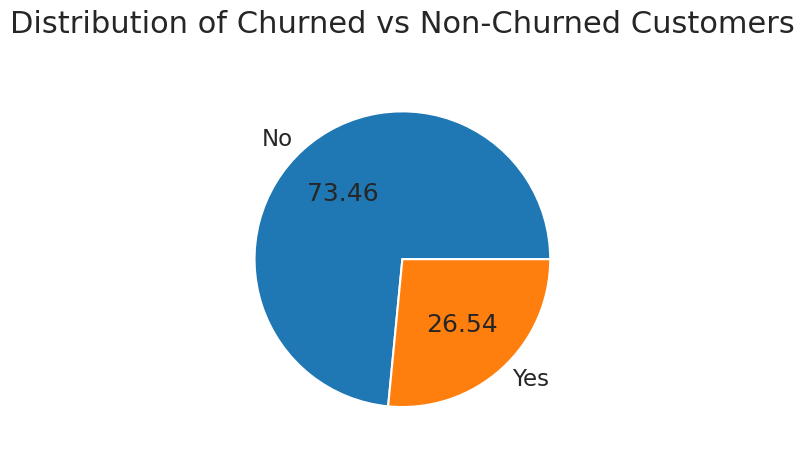

In [93]:
#Churned vs Non-Churned Customers- Pie Chart
plt.pie(df['Churn'].value_counts(),labels=['No','Yes'],autopct='%0.2f')
plt.title('Distribution of Churned vs Non-Churned Customers')

- The dataset is highly imbalanced, with 26.54% churned customers and 73.46% non-churned customers.

## 1. Data Cleaning

#### Check for missing values

In [94]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Text(0.5, 1.0, 'Percentage of Missing values')

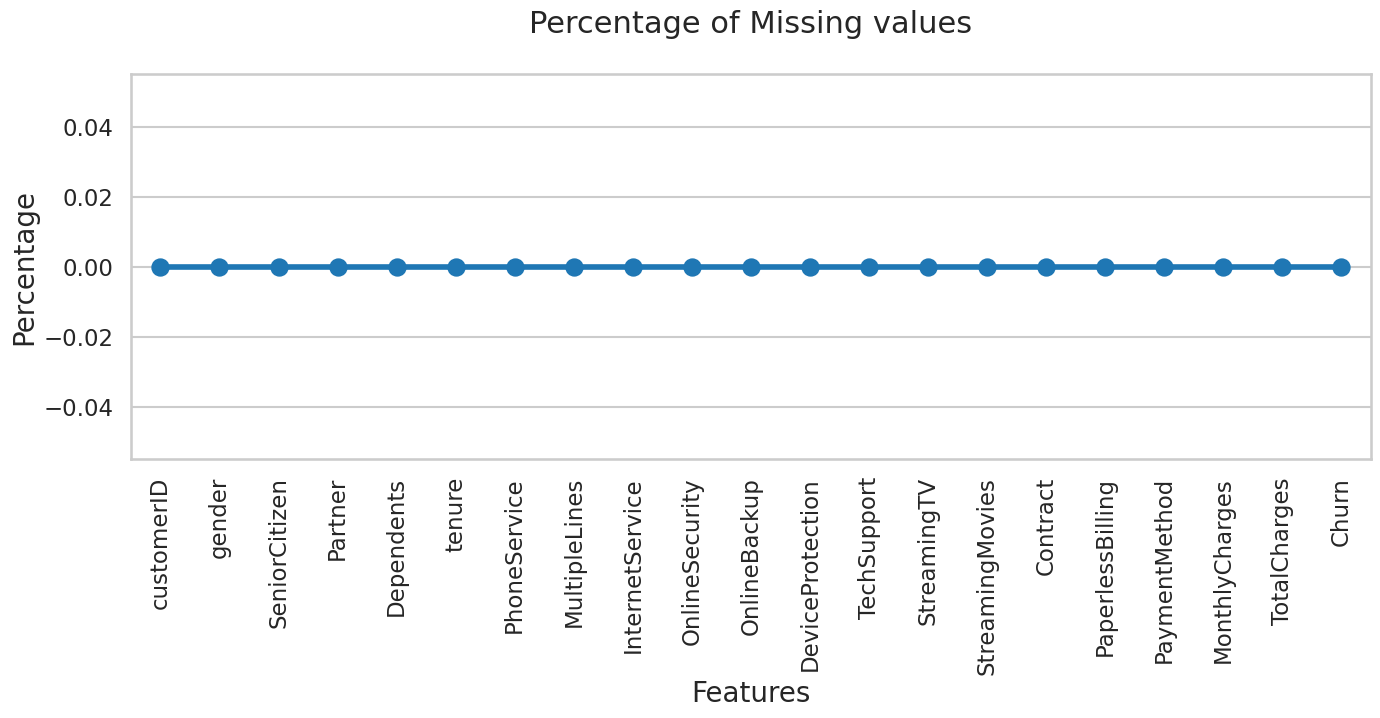

In [95]:
missing_data=pd.DataFrame(((df.isnull().sum())*100)/df.shape[0]).reset_index()

plt.figure(figsize=(16,5))
sns.pointplot(data=missing_data,x='index',y=0)
plt.xticks(rotation=90,fontsize=10)
plt.xlabel('Features')
plt.ylabel('Percentage')
plt.title('Percentage of Missing values')


- No missing values present

#### Check for duplicate rows

In [96]:
df.duplicated().sum()

np.int64(0)

- No duplicate data present

In [97]:
#removed customerID feature as it does not affect churning
df1=df.drop('customerID',axis=1)

In [98]:
#renaming gender-> Gender and tenure-> Tenure
df1=df1.rename(columns={'gender':'Gender','tenure':'Tenure'})

In [99]:
df1.head(2)

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [100]:
#Converting a seniorcitizen feature to a object type
df1['SeniorCitizen']=df1['SeniorCitizen'].astype('object')

In [101]:
df1.dtypes.loc['SeniorCitizen']

dtype('O')

In [102]:
#Converting totalcharges feature to a float type
# df1['totalcharges']=df1['totalcharges'].astype('float64')
df1.TotalCharges = pd.to_numeric(df1.TotalCharges, errors='coerce')

In [103]:
df1.dtypes.loc['TotalCharges']

dtype('float64')

In [104]:
#checking for null values in totalcharges feature after conversion
df1['TotalCharges'].isnull().sum()

np.int64(11)

In [105]:
(df1['TotalCharges'].isnull().sum()/df.shape[0])*100

np.float64(0.1561834445548772)

In [106]:
df1[df1.TotalCharges.isnull()==True]

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


- There are 11 missing values in TotalCharges column after conversion and they 0.15% of whole dataset, it is safe to ignore them from further processing.

In [107]:
df2=df1.copy()

In [108]:
df2.dropna(how='any',inplace=True)

In [109]:
print('Min-',df2['Tenure'].min(),'Max-',df2['Tenure'].max(),'for Tenure feature')

Min- 1 Max- 72 for Tenure feature


#### Created a new feature as TenureGroup from Tenure column

In [110]:
#Grouping the tenure in bins of 12 months
lables=['1-12','13-24','25-36','37-48','49-60','61-72']
bins=[1,13,25,37,49,61,73]
df2['TenureGroup']=pd.cut(df2.Tenure,labels=lables,bins=bins,right=False)

In [111]:
df2['TenureGroup'].value_counts()

,count
TenureGroup,
1-12,2175
61-72,1407
13-24,1024
25-36,832
49-60,832
37-48,762


In [112]:
df2[['Tenure','TenureGroup']].sample(10)

,Tenure,TenureGroup
4116,20,13-24
6706,1,1-12
5460,34,25-36
3879,1,1-12
6177,4,1-12
1889,14,13-24
4358,13,13-24
911,15,13-24
2059,37,37-48
3045,48,37-48


In [113]:
df3=df2.copy()

In [114]:
df3.head()

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1-12
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25-36
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1-12
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37-48
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1-12


In [115]:
# Checking unique categories in each categorical feature to ensure there are no redundant or inconsistent categories before analysis.
for col in df3.columns:
    if df3[col].dtype != np.number:
        print(f"\nValue counts for column: {col}")
        print(df3[col].value_counts())


Value counts for column: Gender
Gender
Male      3549
Female    3483
Name: count, dtype: int64

Value counts for column: SeniorCitizen
SeniorCitizen
0    5890
1    1142
Name: count, dtype: int64

Value counts for column: Partner
Partner
No     3639
Yes    3393
Name: count, dtype: int64

Value counts for column: Dependents
Dependents
No     4933
Yes    2099
Name: count, dtype: int64

Value counts for column: Tenure
Tenure
1     613
72    362
2     238
3     200
4     176
     ... 
38     59
28     57
39     56
44     51
36     50
Name: count, Length: 72, dtype: int64

Value counts for column: PhoneService
PhoneService
Yes    6352
No      680
Name: count, dtype: int64

Value counts for column: MultipleLines
MultipleLines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64

Value counts for column: InternetService
InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

Value counts for column:

/tmp/ipython-input-2379267329.py:3: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  if df3[col].dtype != np.number:
/tmp/ipython-input-2379267329.py:3: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  if df3[col].dtype != np.number:
/tmp/ipython-input-2379267329.py:3: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  if df3[col].dtype != np.number:
/tmp/ipython-input-2379267329.py:3: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  if df3[col].dtype != np.number:
/tmp/ipython-input-2379267329.py:3: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecate

In [116]:
df3.head()

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1-12
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25-36
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1-12
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37-48
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1-12


## `EDA`

### Univariate Analysis

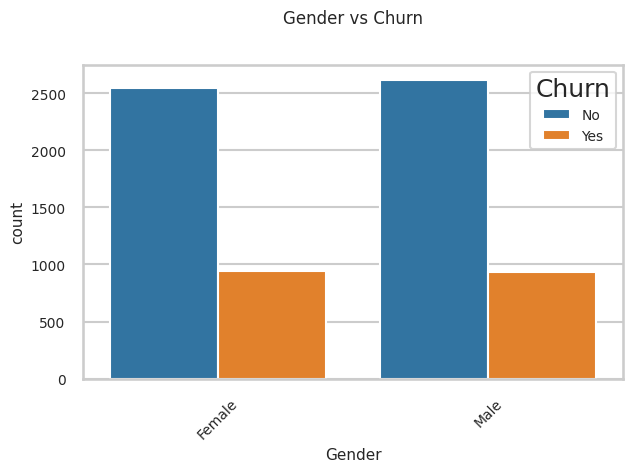

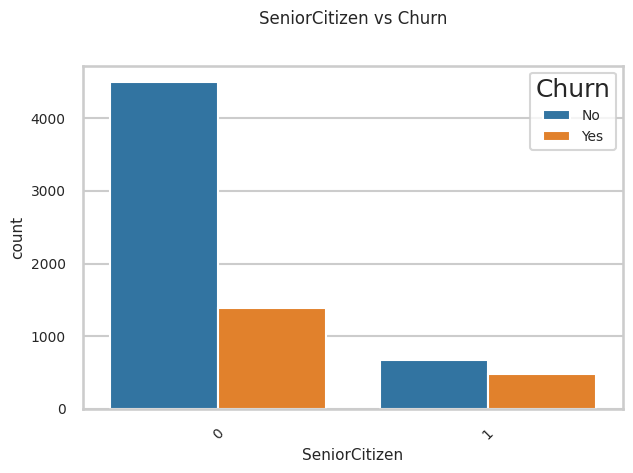

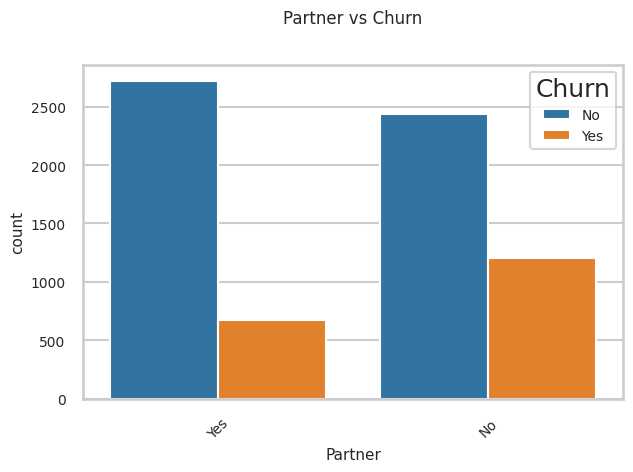

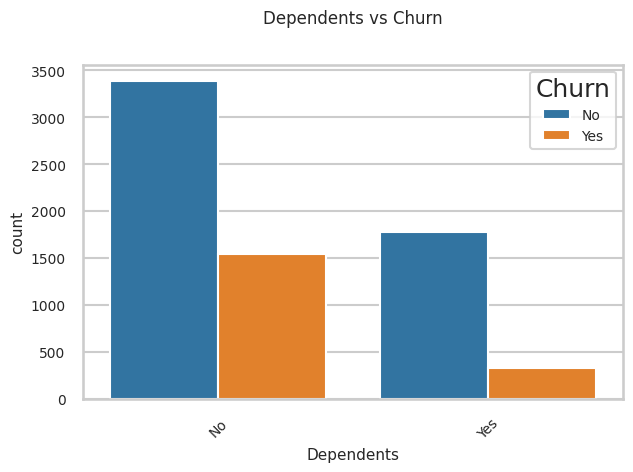

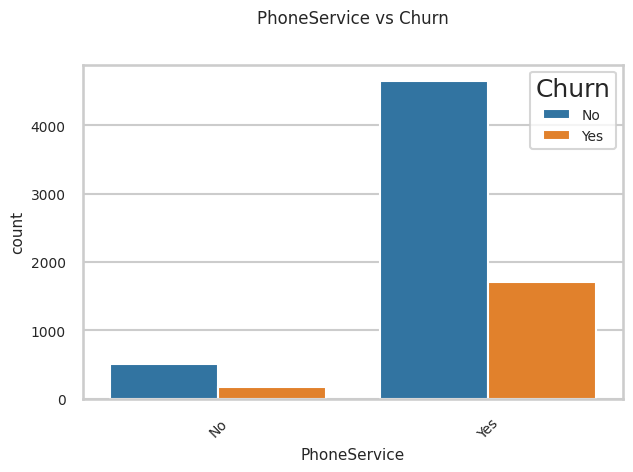

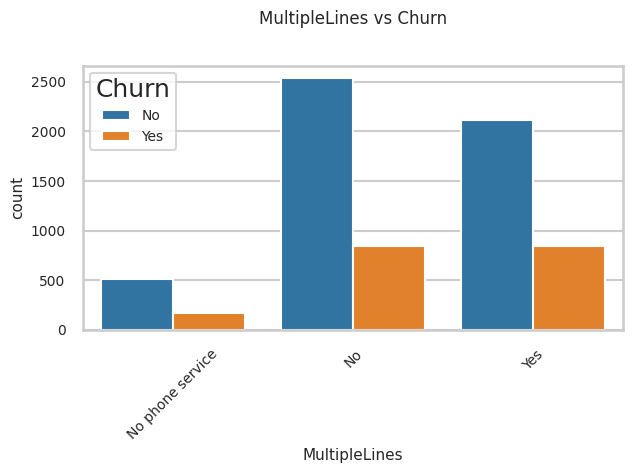

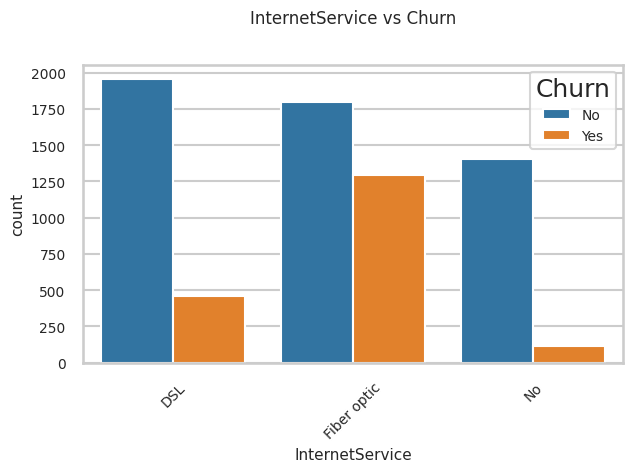

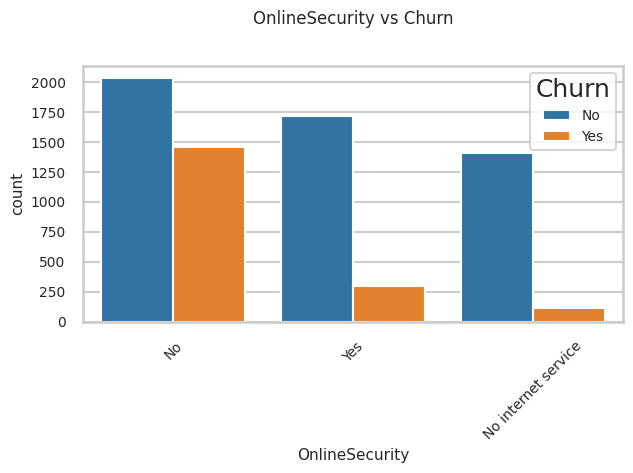

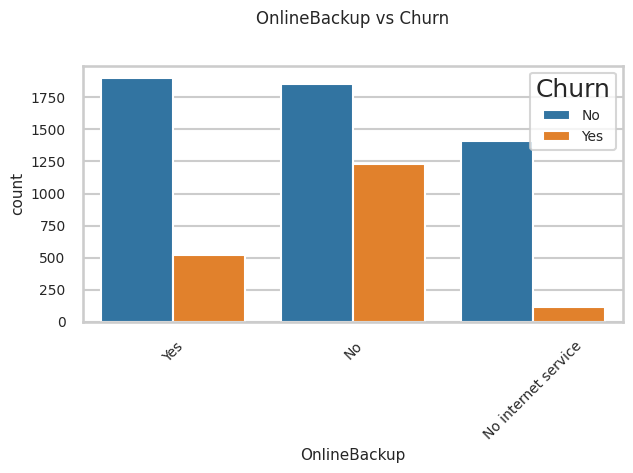

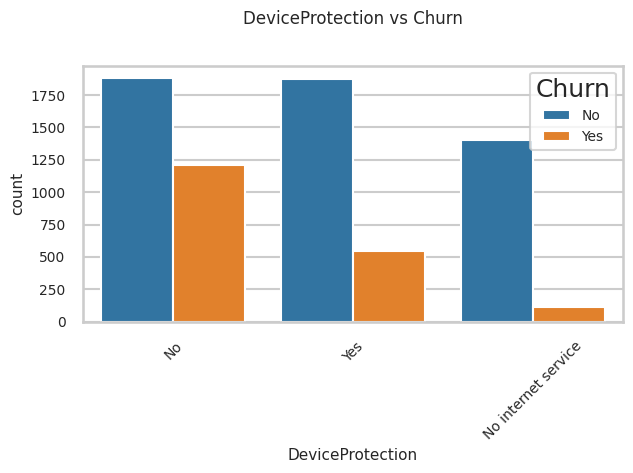

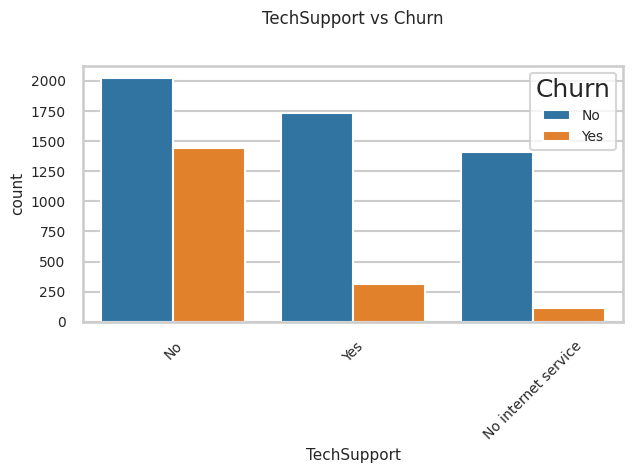

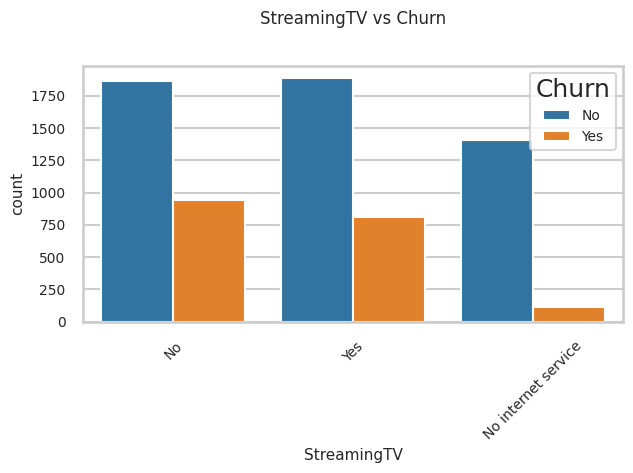

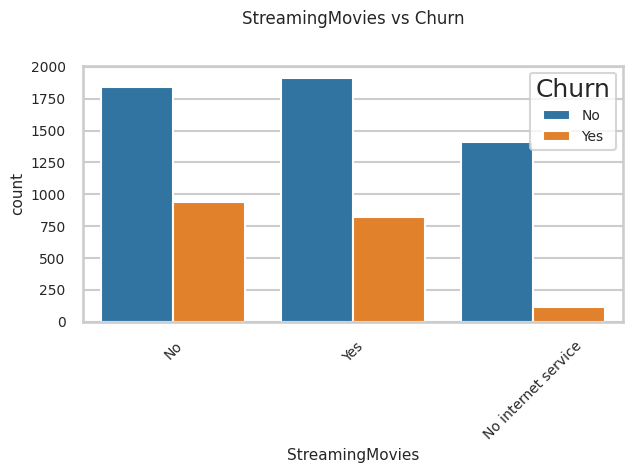

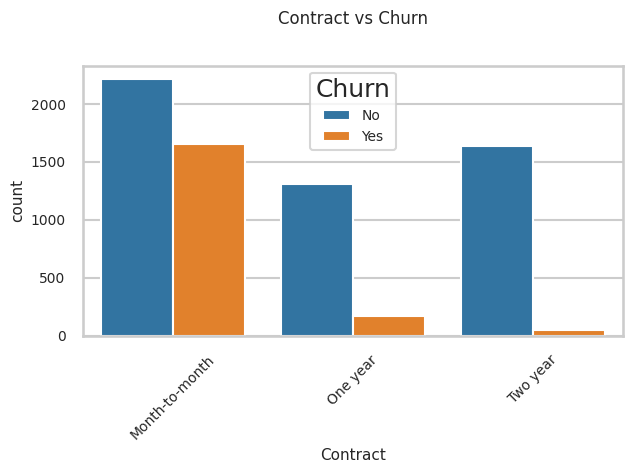

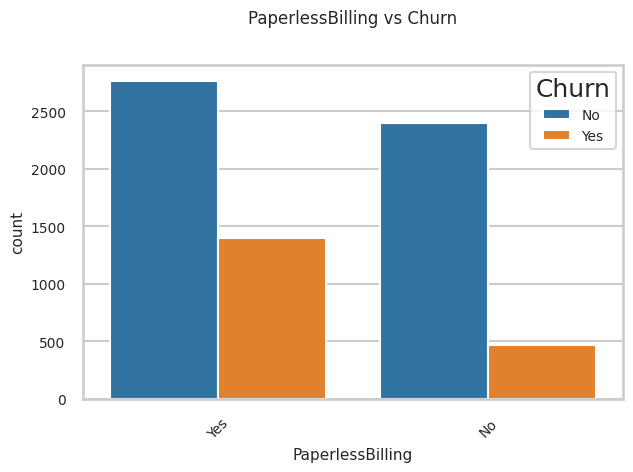

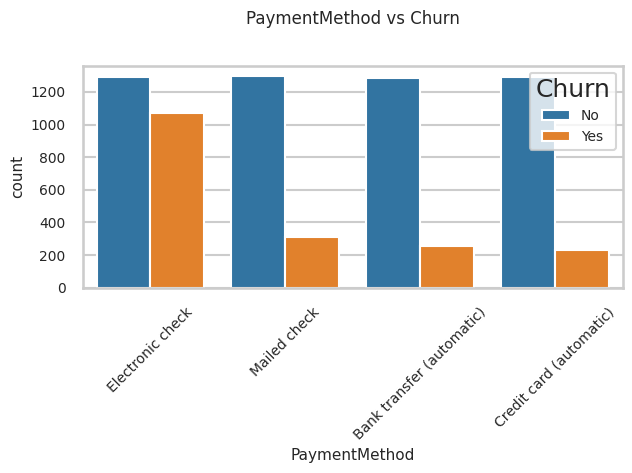

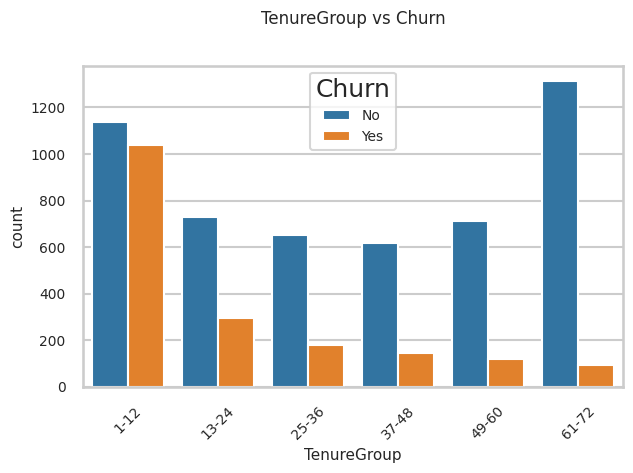

In [197]:
for i,predictor in enumerate(df3.drop(columns=['Churn', 'TotalCharges', 'MonthlyCharges','Tenure'])):
  plt.figure(i)
  sns.countplot(data=df3,x=predictor,hue='Churn')
  plt.title(f"{predictor} vs Churn")
  plt.xticks(rotation=45)
  plt.tight_layout()

### `Insights from Univariate Analysis:`
Senior citizens are more likely to churn → 41%

Customers with No partner are more likely to churn → 32%

Customers with No dependents are more likely to churn → 31%

Customers with MultipleLines = Yes churn more → 28%

Customers using Fiber Optic internet churn more → 41%

Customers with No Online Security churn more → 41%

Customers with No Online Backup churn more → 39.94%

Customers with No Device Protection churn more → 39.14%

Customers with No Tech Support churn more → 41.65%

StreamingTV:

No → 33%

Yes → 30%

StreamingMovies:

No → 33%

Yes → 29%

Contract (Month-to-Month) churn rate → 41%

Paperless Billing = Yes churn rate → 33%

Payment Method: Electronic Check churn rate → 45%

Tenure Group 1–12 months churn rate → 47.67%

### Numerical Analysis

In [118]:
df4=df3.copy()

In [119]:
#Converting the target variable churn into binary numeric variable
df4['Churn']=np.where(df4.Churn=='Yes',1,0)

In [120]:
df4.head()

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1-12
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,0,25-36
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,1-12
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,37-48
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1-12


In [121]:
#converting all categorical variables into dummy variables
df4=pd.get_dummies(df4)

In [122]:
df4.head()

,Tenure,MonthlyCharges,TotalCharges,Churn,Gender_Female,Gender_Male,SeniorCitizen_0,SeniorCitizen_1,Partner_No,Partner_Yes,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_1-12,TenureGroup_13-24,TenureGroup_25-36,TenureGroup_37-48,TenureGroup_49-60,TenureGroup_61-72
0,1,29.85,29.85,0,True,False,True,False,False,True,...,False,False,True,False,True,False,False,False,False,False
1,34,56.95,1889.50,0,False,True,True,False,True,False,...,False,False,False,True,False,False,True,False,False,False
2,2,53.85,108.15,1,False,True,True,False,True,False,...,False,False,False,True,True,False,False,False,False,False
3,45,42.30,1840.75,0,False,True,True,False,True,False,...,True,False,False,False,False,False,False,True,False,False
4,2,70.70,151.65,1,True,False,True,False,True,False,...,False,False,True,False,True,False,False,False,False,False


Text(0.5, 1.0, 'Monthly vs Total Charges')

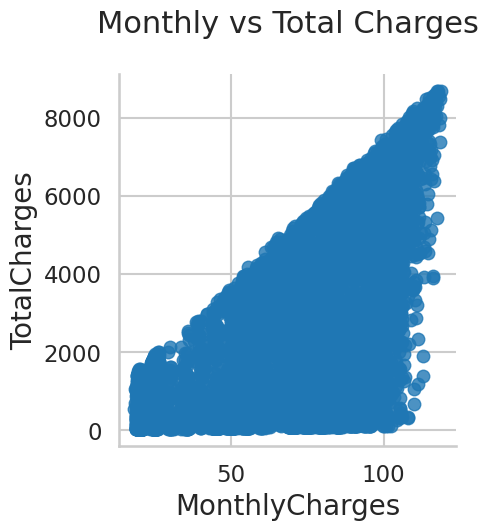

In [123]:
sns.lmplot(data=df4,x='MonthlyCharges',y='TotalCharges',fit_reg=False)
plt.title('Monthly vs Total Charges')

In [124]:
#correlation
df4['MonthlyCharges'].corr(df4['TotalCharges'])

np.float64(0.6510648032262027)

- Total charges increases as monthly charges increases - as expected

#### Filtered the dataset into churned and non-churned customer groups.

In [125]:
df4_target1=df4[df4.Churn==1]
df4_target0=df4[df4.Churn==0]

Text(0.5, 1.0, 'Monthly Charges by churn')

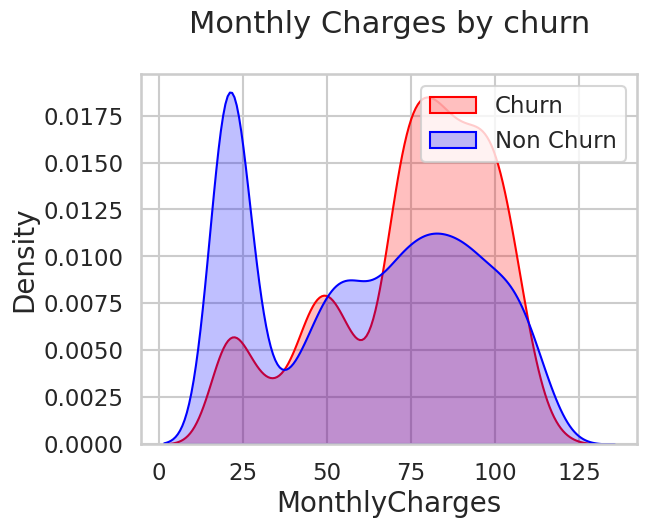

In [126]:
sns.kdeplot(data=df4_target1,x='MonthlyCharges',color='Red',fill=True)
sns.kdeplot(data=df4_target0,x='MonthlyCharges',color='Blue',fill=True)
plt.legend(['Churn','Non Churn'],loc='upper right')
plt.title('Monthly Charges by churn')

- There are more churned customers in the MonthlyCharges range of 70–110, meaning churn is higher when the monthly charges are high.
- There are more non-churned customers in the MonthlyCharges range of 4–35, meaning customers with low monthly charges usually do not churn.

Text(0.5, 1.0, 'Total Charges by churn')

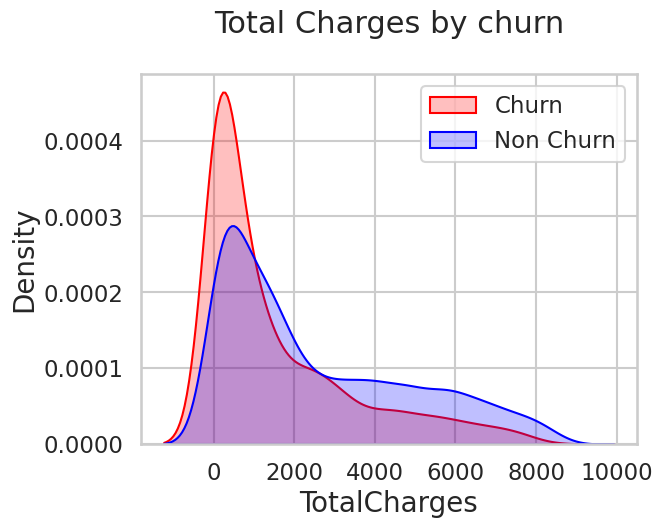

In [127]:
sns.kdeplot(data=df4_target1,x='TotalCharges',color='Red',fill=True)
sns.kdeplot(data=df4_target0,x='TotalCharges',color='Blue',fill=True)
plt.legend(['Churn','Non Churn'],loc='upper right')
plt.title('Total Charges by churn')

- A larger number of customers tend to churn when TotalCharges are low.

Text(0.5, 1.0, 'Tenure by churn')

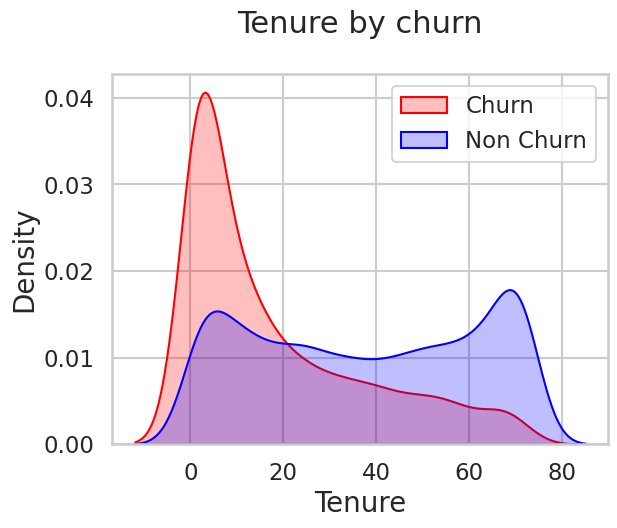

In [128]:
sns.kdeplot(data=df4_target1,x='Tenure',color='Red',fill=True)
sns.kdeplot(data=df4_target0,x='Tenure',color='Blue',fill=True)
plt.legend(['Churn','Non Churn'],loc='upper right')
plt.title('Tenure by churn')

- Customers with shorter Tenure are more likely to chur

Text(0, 0.5, 'Correlation')

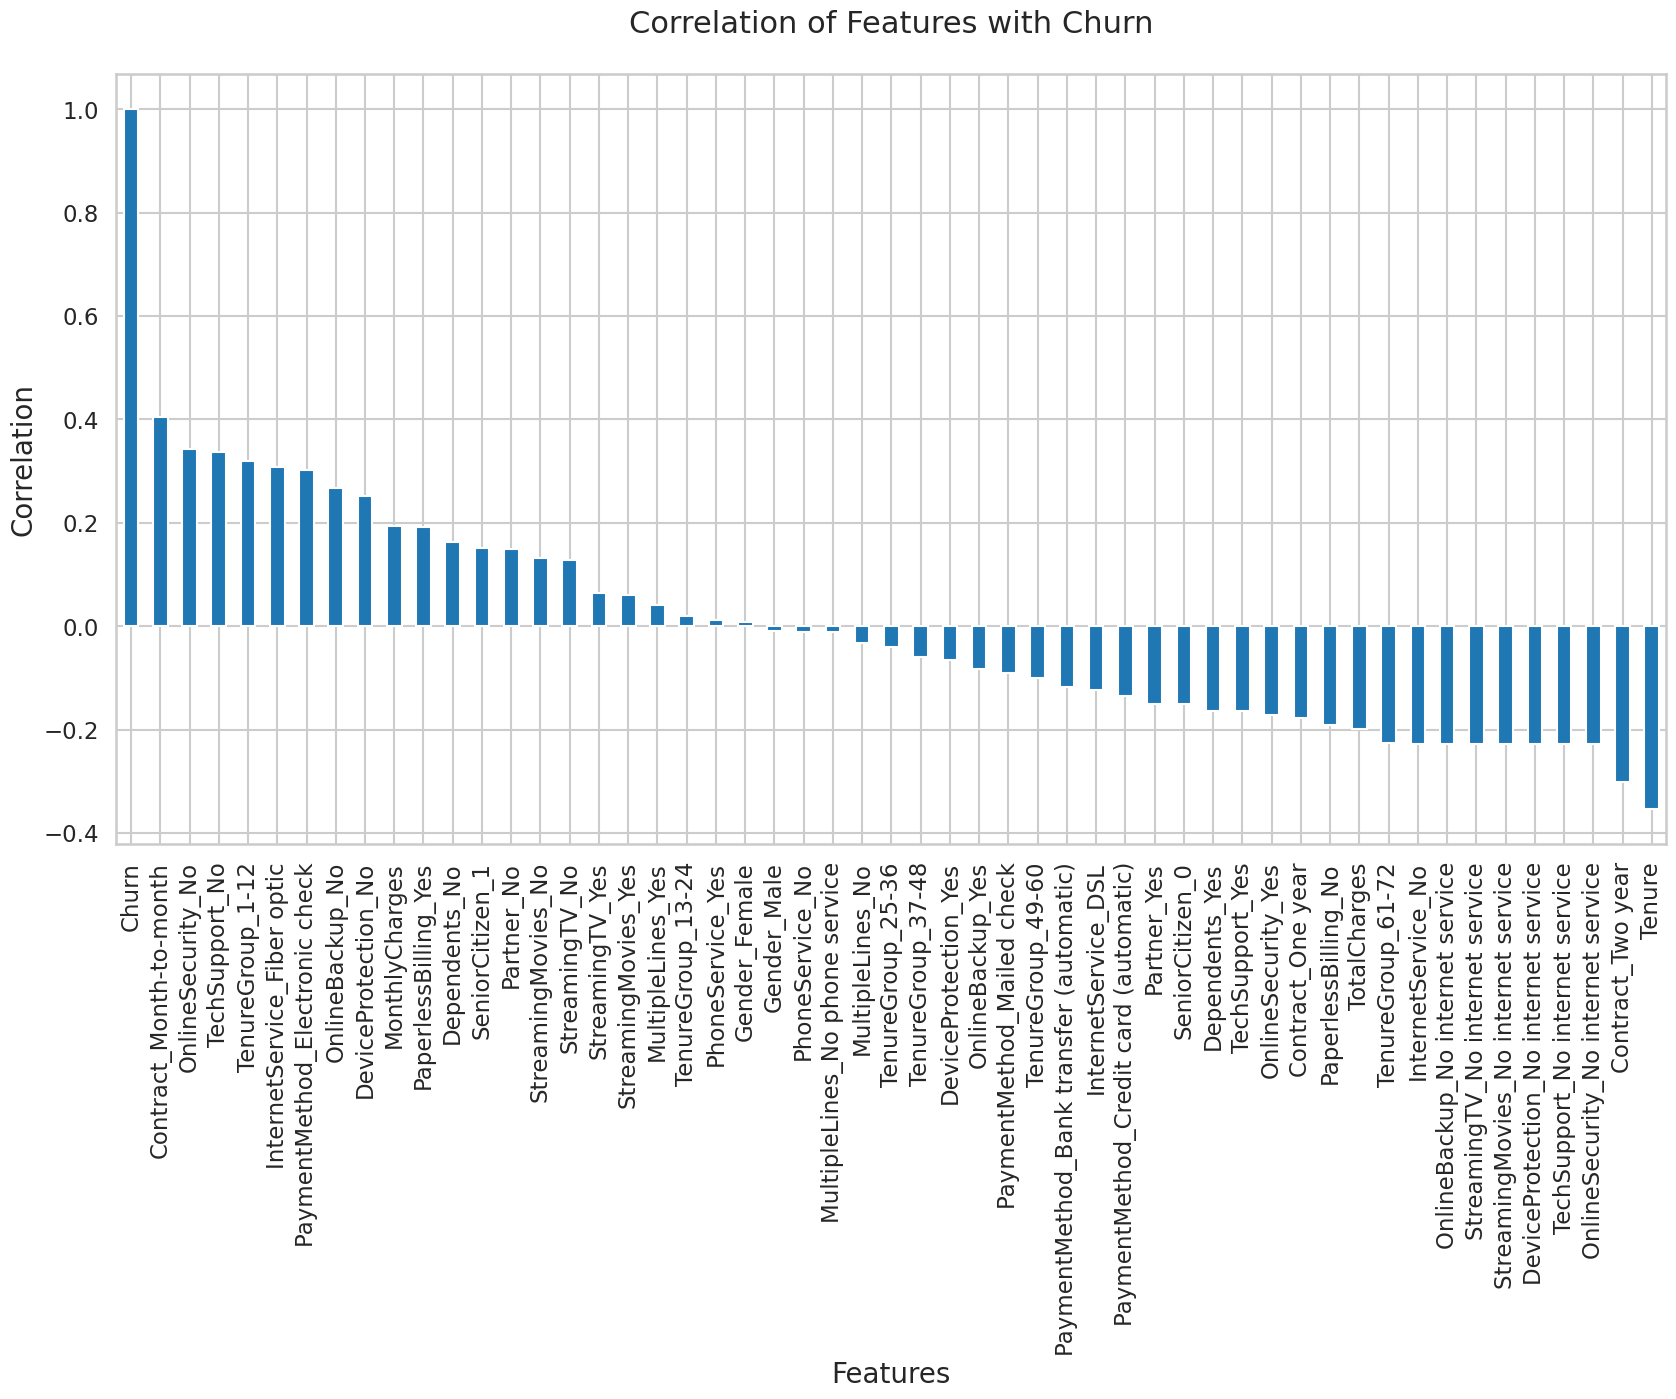

In [129]:
plt.figure(figsize=(20,10))
df4.corr().loc['Churn'].sort_values(ascending=False).plot(kind='bar')
plt.title("Correlation of Features with Churn")
plt.xlabel('Features')
plt.ylabel('Correlation')

- People with No internet service are most of non churners.
- Customers with a Two-Year contract are more likely to stay (non-churners).
- Customers with longer Tenure, e.g., Tenure_Group_61-72, tend to churn less.
- factors like PhoneService,Gender,MultipleLines have almost no impact on churn.

Text(0.5, 1.0, 'Feature Correlation Heatmap')

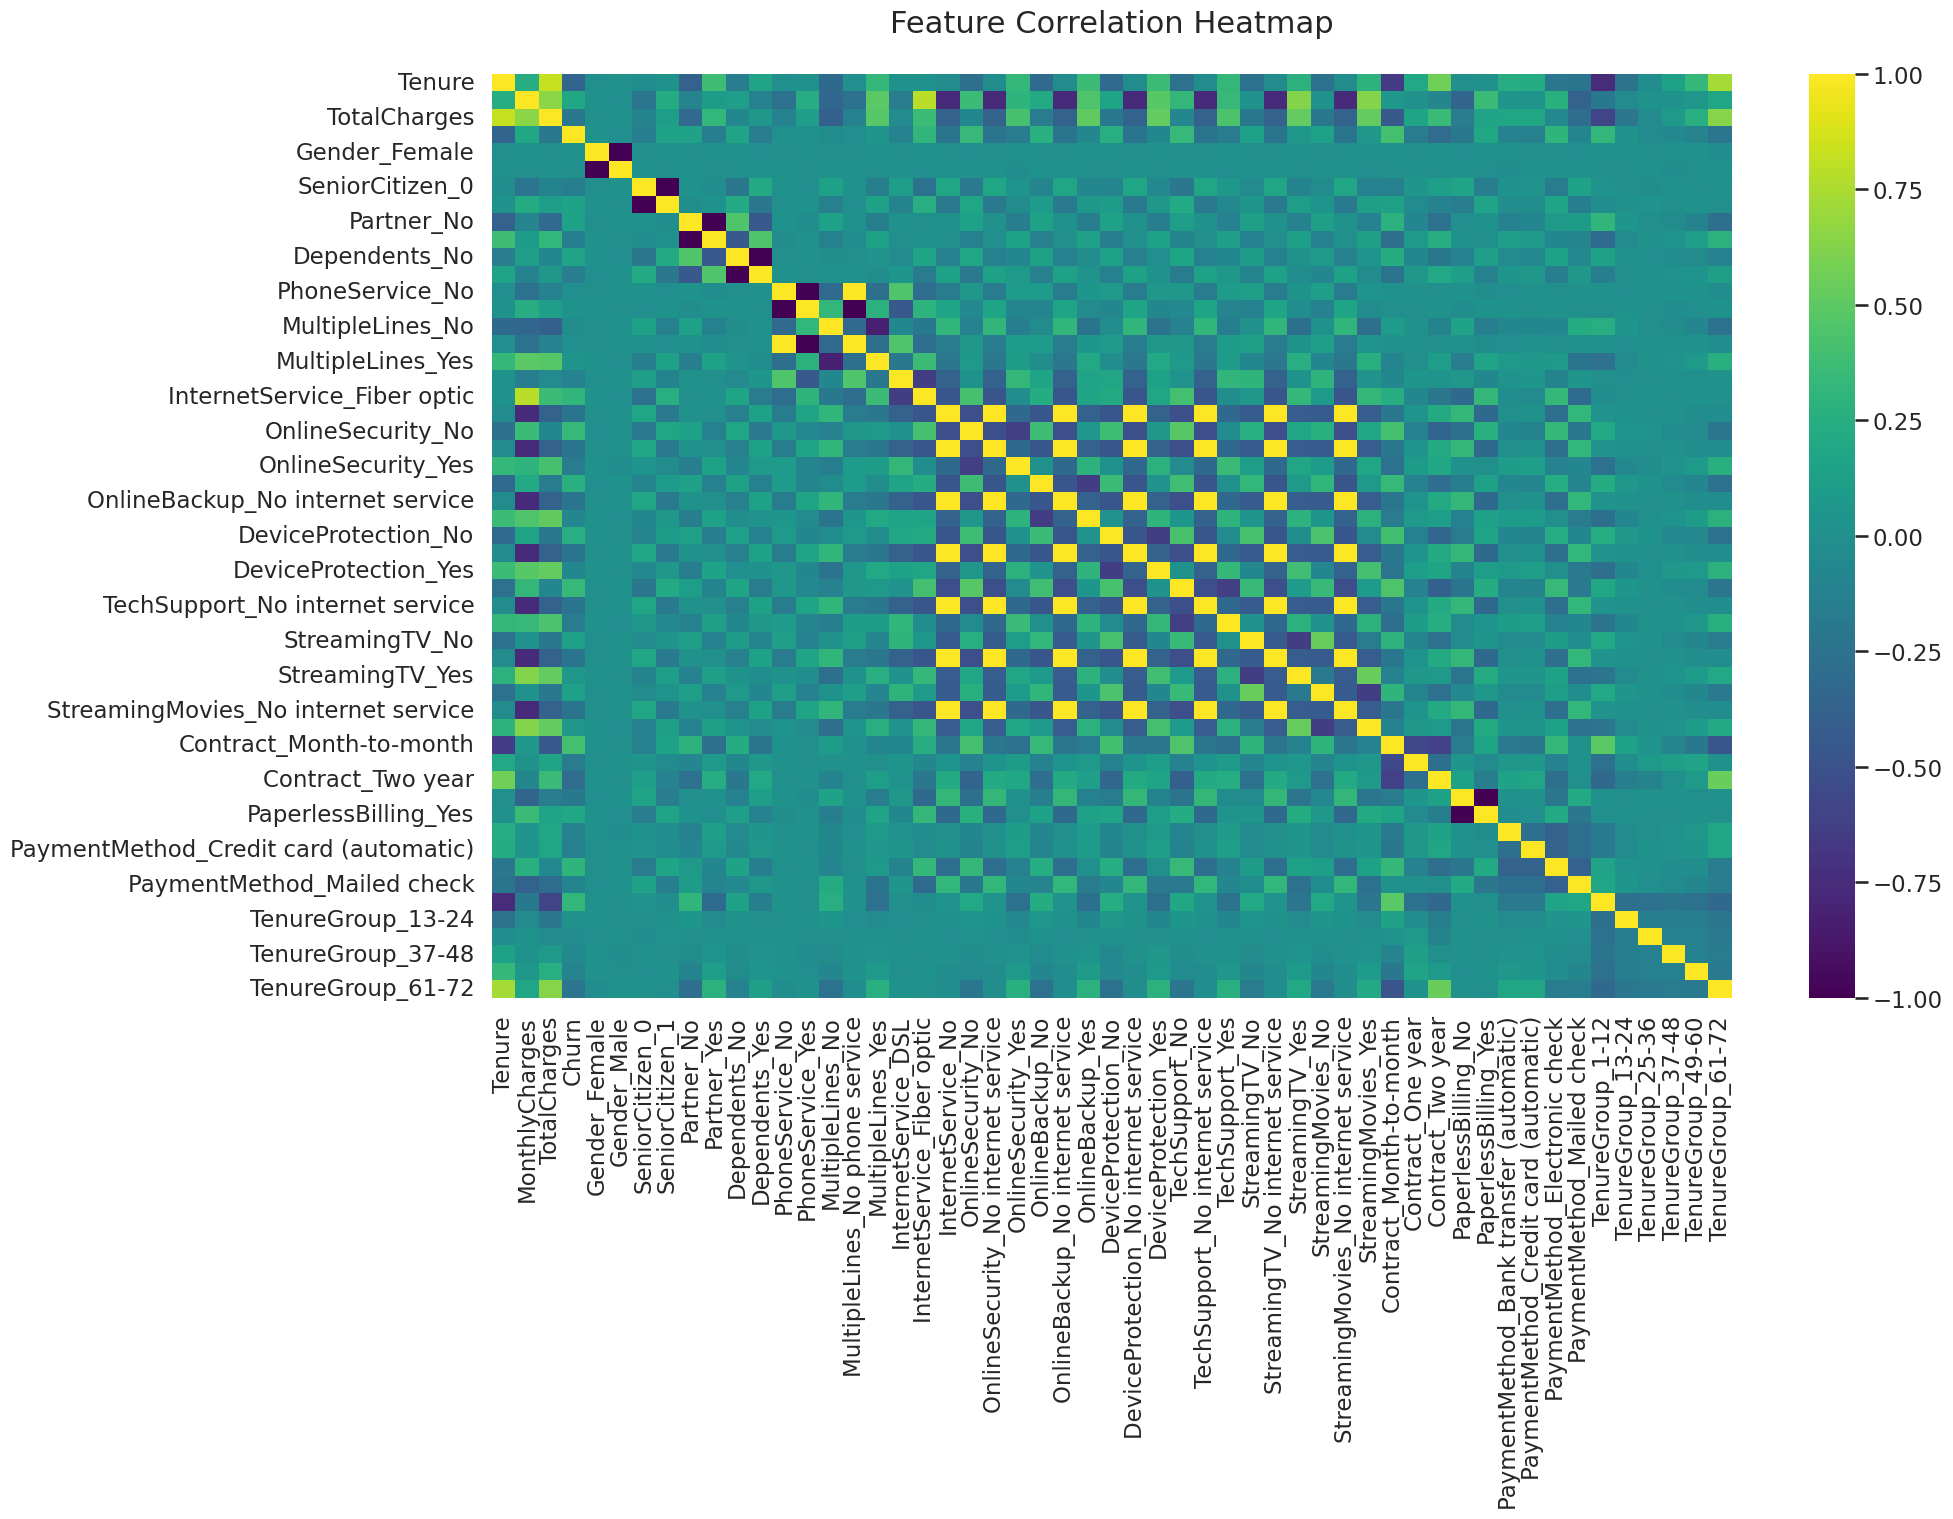

In [130]:
plt.figure(figsize=(20,12))
sns.heatmap(df4.corr(),cmap='viridis')
plt.title("Feature Correlation Heatmap")

`Insights from Heatmap`
- MonthlyCharges increase with Fiber optic internet usage, as fiber plans are generally more expensive and customers with higher monthly charges are more likely to churn.

- TotalCharges increase with higher tenure groups (especially 61–72 months), which is expected since long-term customers accumulate larger bills over time.

- Customers without add-on services (tech support, device protection, backups) show a higher correlation with churn, whereas customers who subscribe to additional services tend to stay longer.

- Electronic check users are more likely to churn, while customers paying through credit card, bank transfer, or mailed check are less likely to churn.

- Higher tenure groups correlate negatively with churn, meaning long-standing customers are less likely to leave.

- One-year and two-year contract types have a strong negative correlation with churn, confirming that longer commitments reduce churn.

- PaperlessBilling shows a slight positive correlation with churn, but the effect is small.

- Gender has no meaningful correlation with churn.

- SeniorCitizen shows a weak positive correlation, indicating older customers churn slightly more, but the effect is not strong.


🔥 Top churn drivers

Month-to-month contract

Low tenure (new users churn most)

High monthly charges

Fiber optic internet

Electronic check payment

🧊 Top factors reducing churn

Two-year contracts

High tenure groups

Having online security / tech support add-ons

Paying via card/bank transfer

## Bivariate Analysis

In [131]:
df5=df3.copy()

In [132]:
df5['Churn']=np.where(df5.Churn=='Yes',1,0)
df5_target1=df5[df5.Churn==1]
df5_target0=df5[df5.Churn==0]

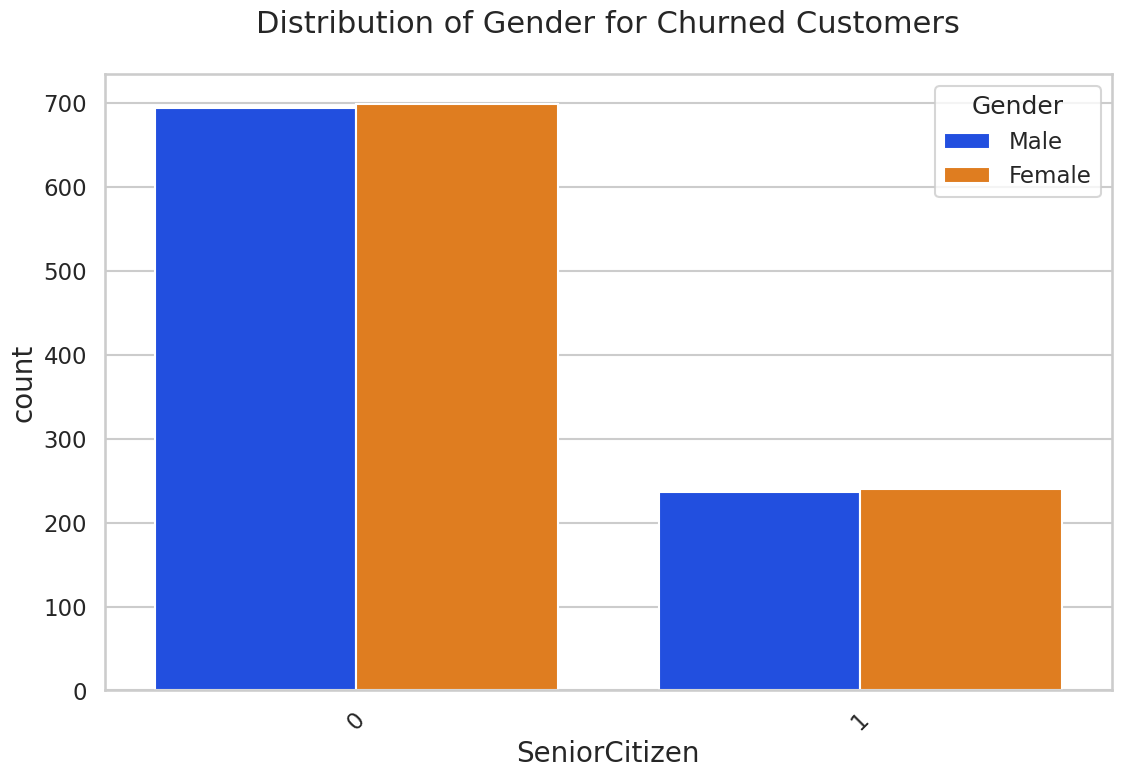

In [133]:
def uniplot(df,col,title,hue =None):

    sns.set_style('whitegrid')
    sns.set_context('talk')
    plt.rcParams["axes.labelsize"] = 20
    plt.rcParams['axes.titlesize'] = 22
    plt.rcParams['axes.titlepad'] = 30


    temp = pd.Series(data = hue)
    fig, ax = plt.subplots()
    width = len(df[col].unique()) + 7 + 4*len(temp.unique())
    fig.set_size_inches(width , 8)
    plt.xticks(rotation=45)
    plt.title(title)
    ax = sns.countplot(data = df, x= col, order=df[col].value_counts().index,hue = hue,palette='bright')

    plt.show()

uniplot(df5_target1,col='SeniorCitizen',title='Distribution of Gender for Churned Customers',hue='Gender')

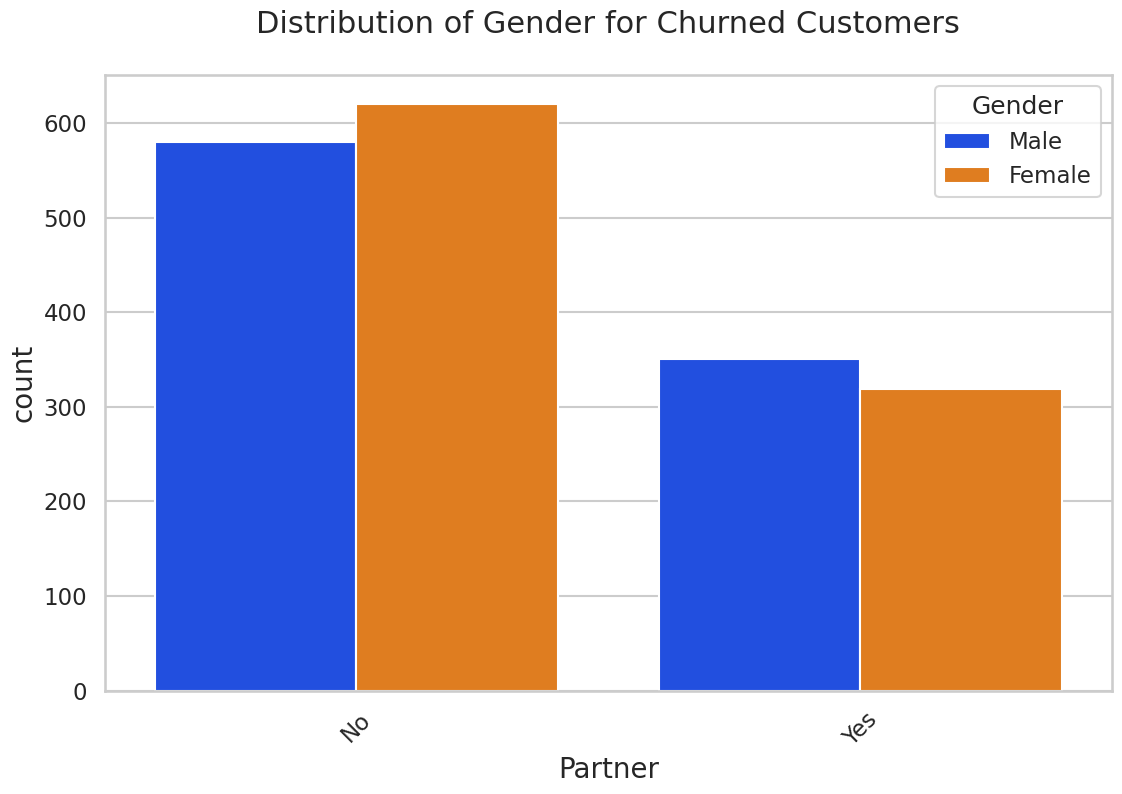

In [134]:
uniplot(df5_target1,col='Partner',title='Distribution of Gender for Churned Customers',hue='Gender')

- Single females are the #1 highest-risk segment
- Males with with partner are more likelit to churn that females

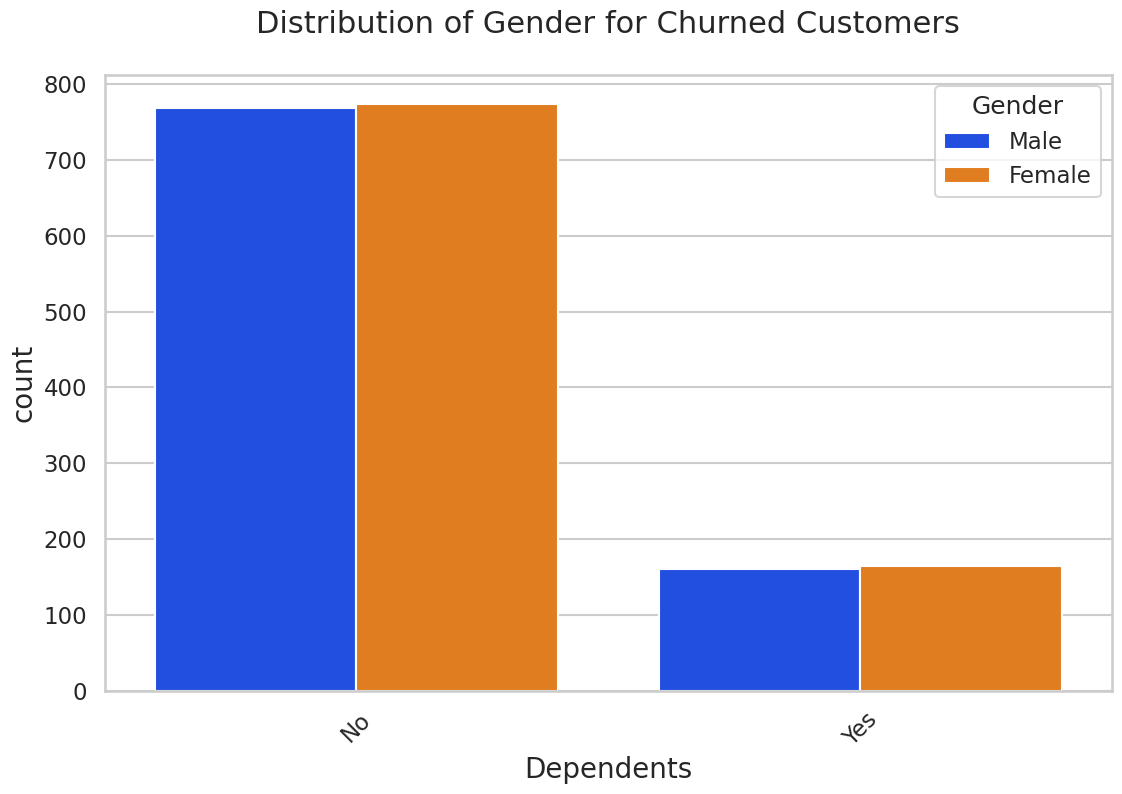

In [135]:
uniplot(df5_target1,col='Dependents',title='Distribution of Gender for Churned Customers',hue='Gender')

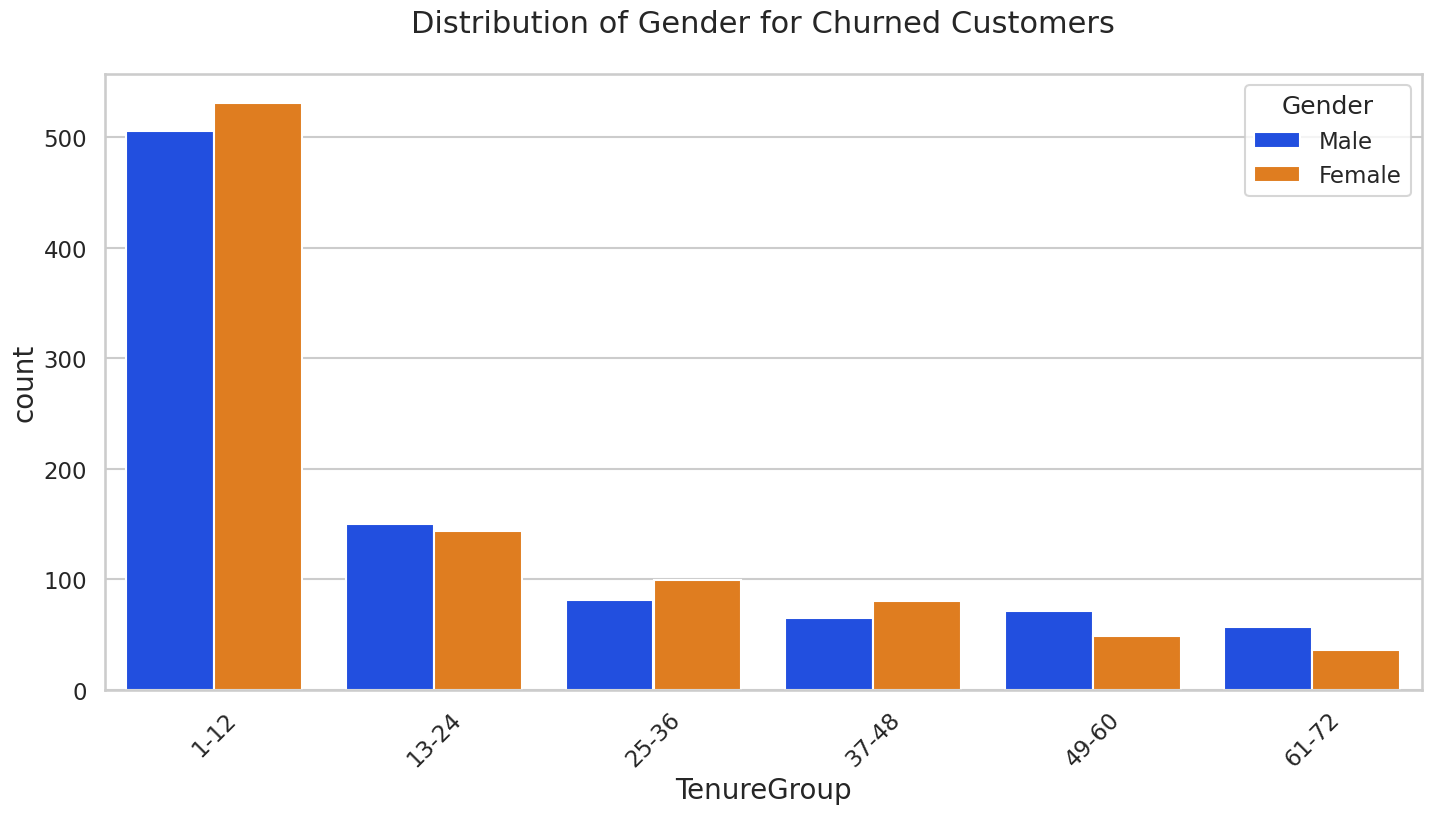

In [136]:
uniplot(df5_target1,col='TenureGroup',title='Distribution of Gender for Churned Customers',hue='Gender')

- In the critical first year, females churn slightly more than males

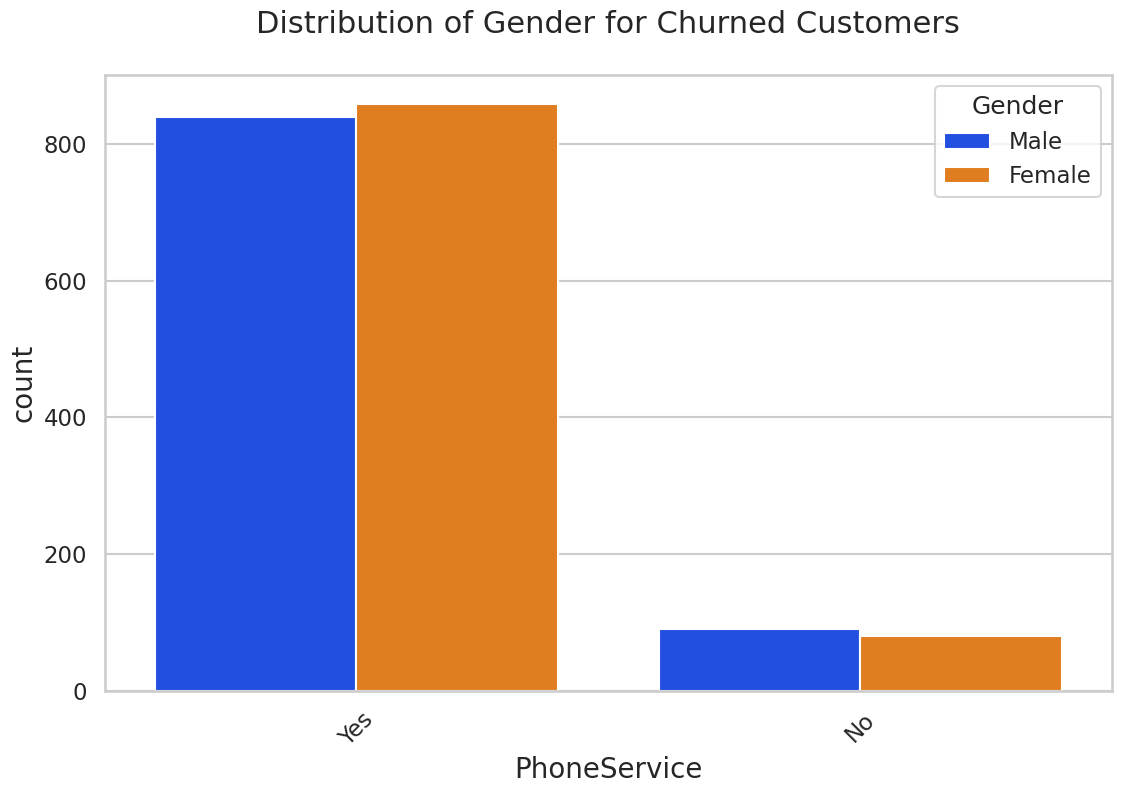

In [137]:
uniplot(df5_target1,col='PhoneService',title='Distribution of Gender for Churned Customers',hue='Gender')

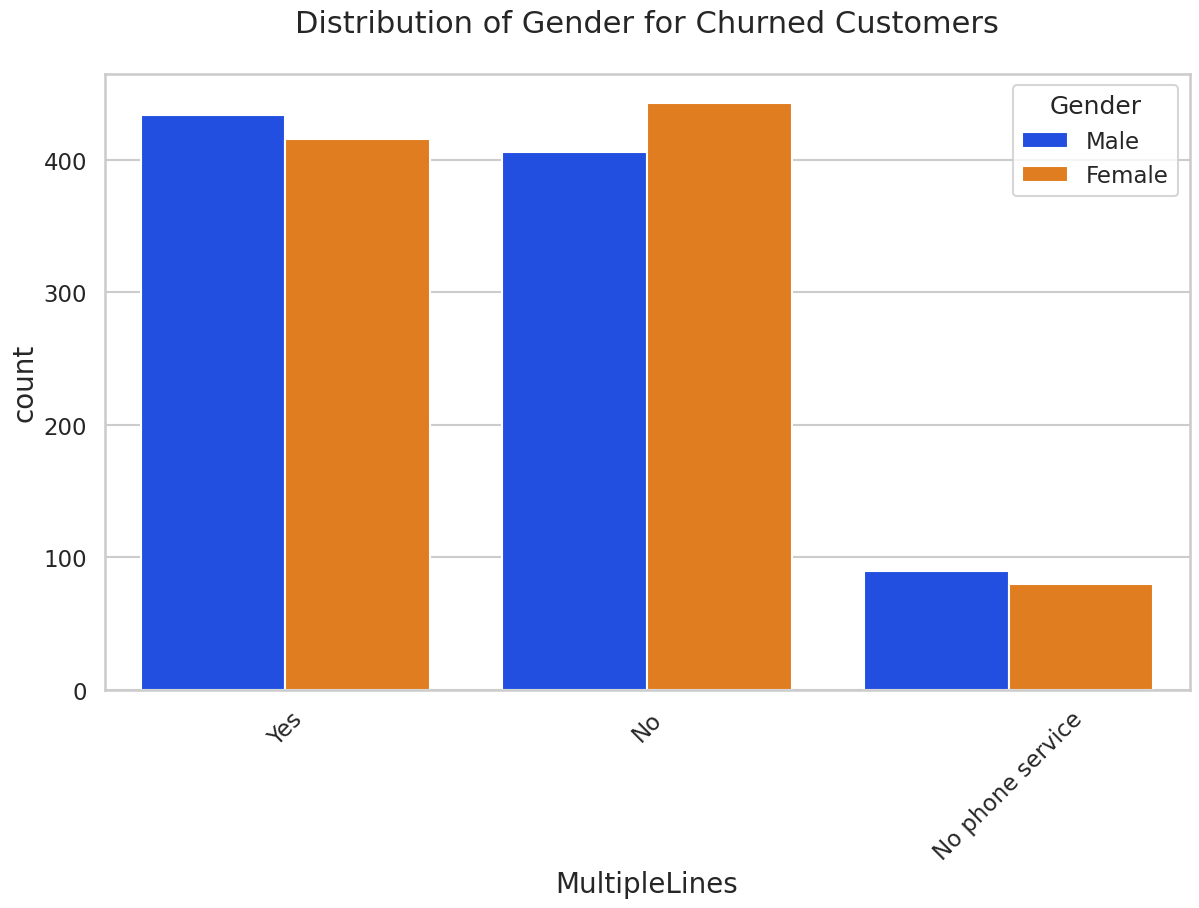

In [138]:
uniplot(df5_target1,col='MultipleLines',title='Distribution of Gender for Churned Customers',hue='Gender')

- Customers with “No phone service” (likely internet-only customers) churn much less.

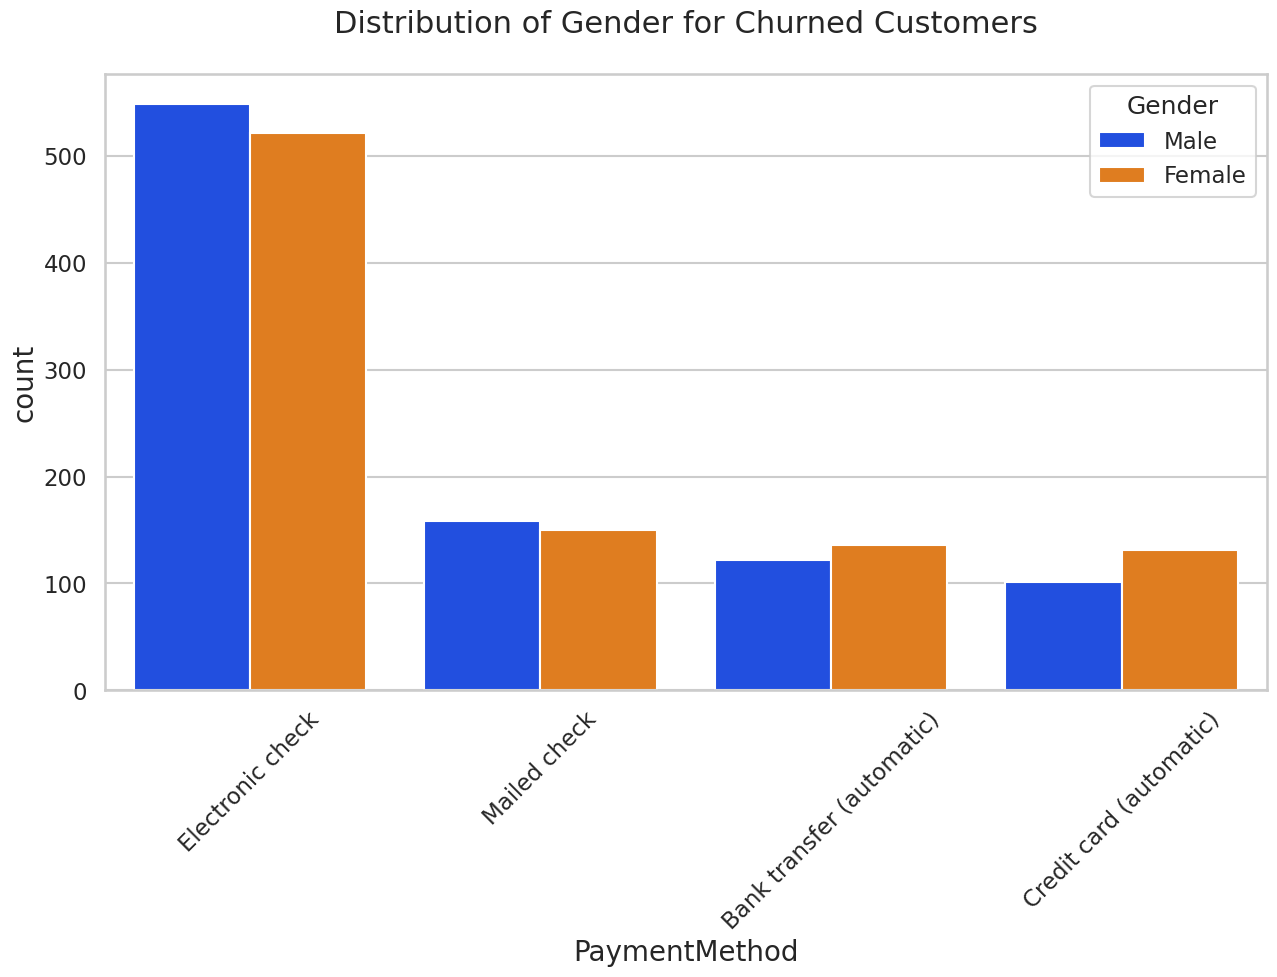

In [139]:
uniplot(df5_target1,col='PaymentMethod',title='Distribution of Gender for Churned Customers',hue='Gender')

- Automatic payments (Bank transfer + Credit card) dramatically reduce churn

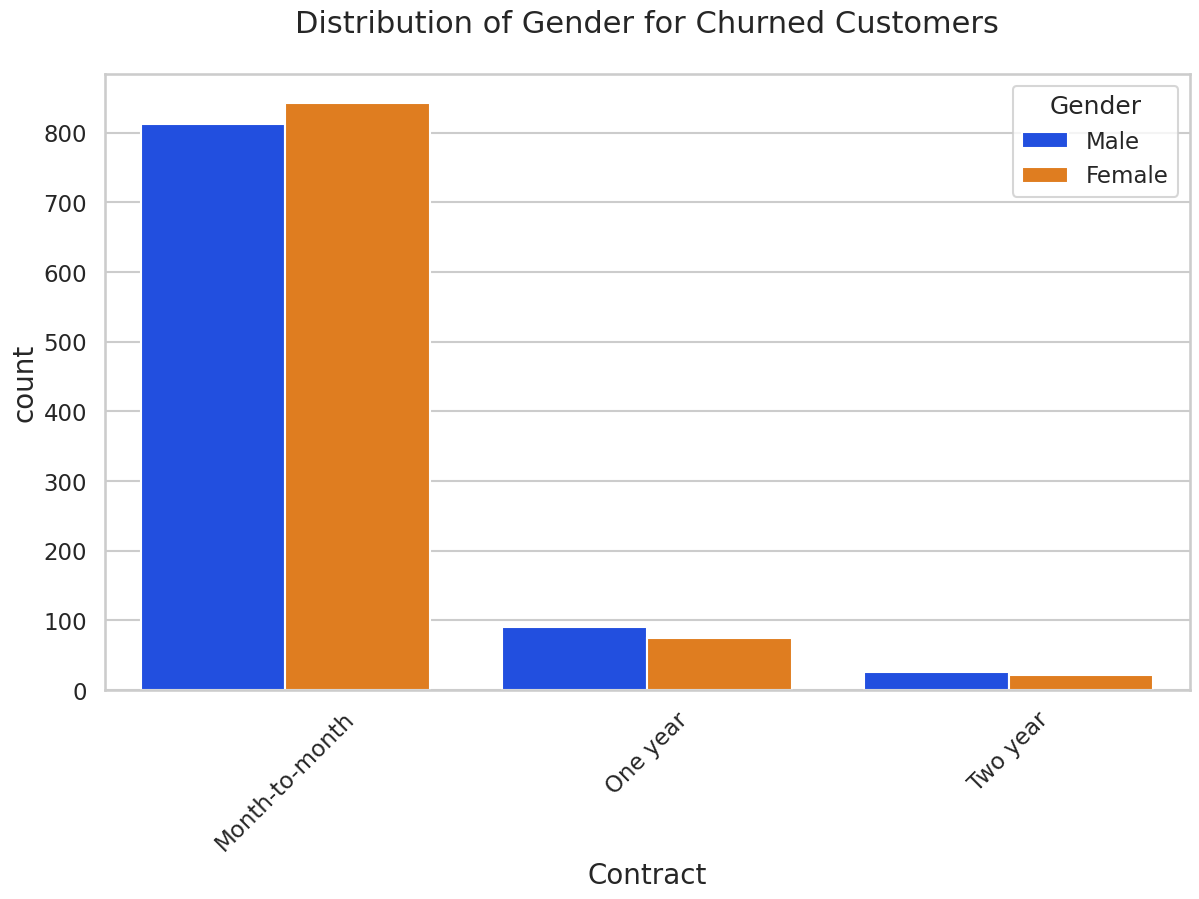

In [140]:
uniplot(df5_target1,col='Contract',title='Distribution of Gender for Churned Customers',hue='Gender')

- more female churners in Month to month contract

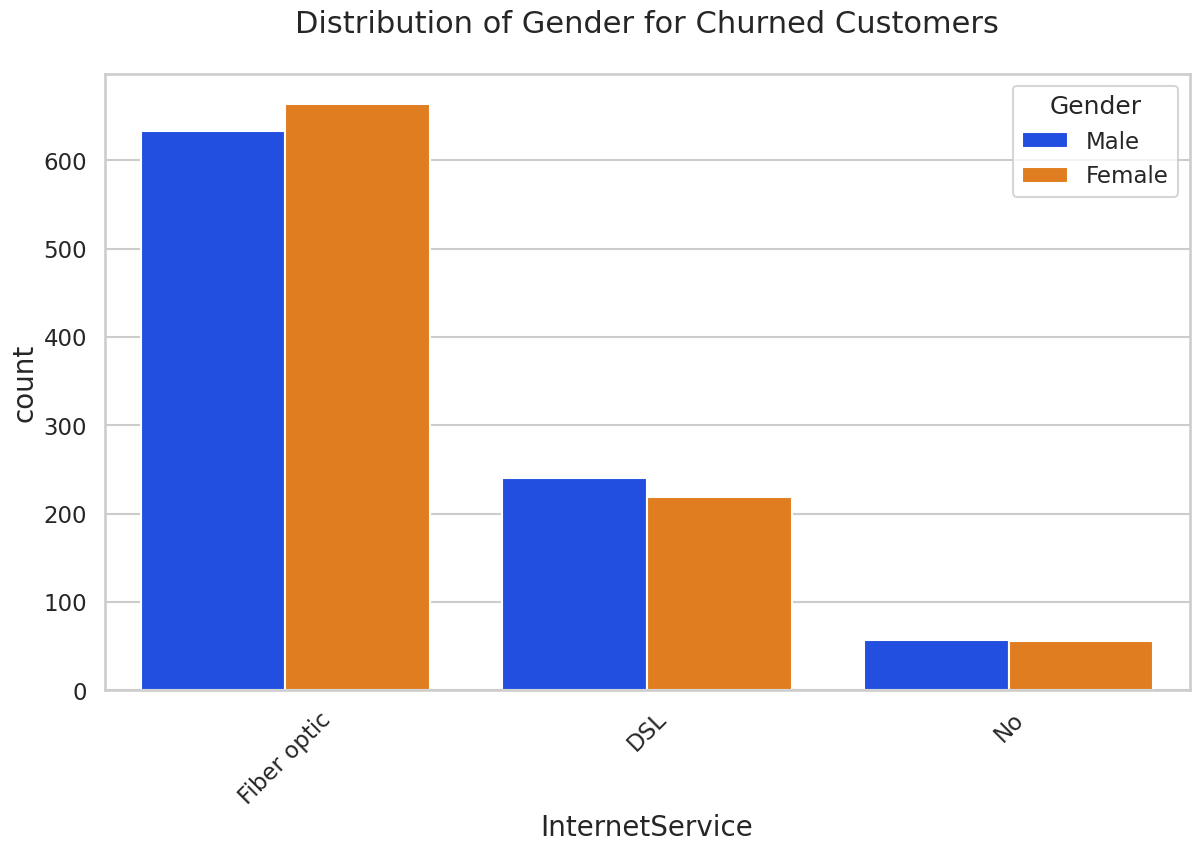

In [141]:
uniplot(df5_target1,col='InternetService',title='Distribution of Gender for Churned Customers',hue='Gender')

 - DSL customers are reasonably sticky, and “No internet” customers almost never churn
 - more feamles churners in fibre optic and more males in DSL

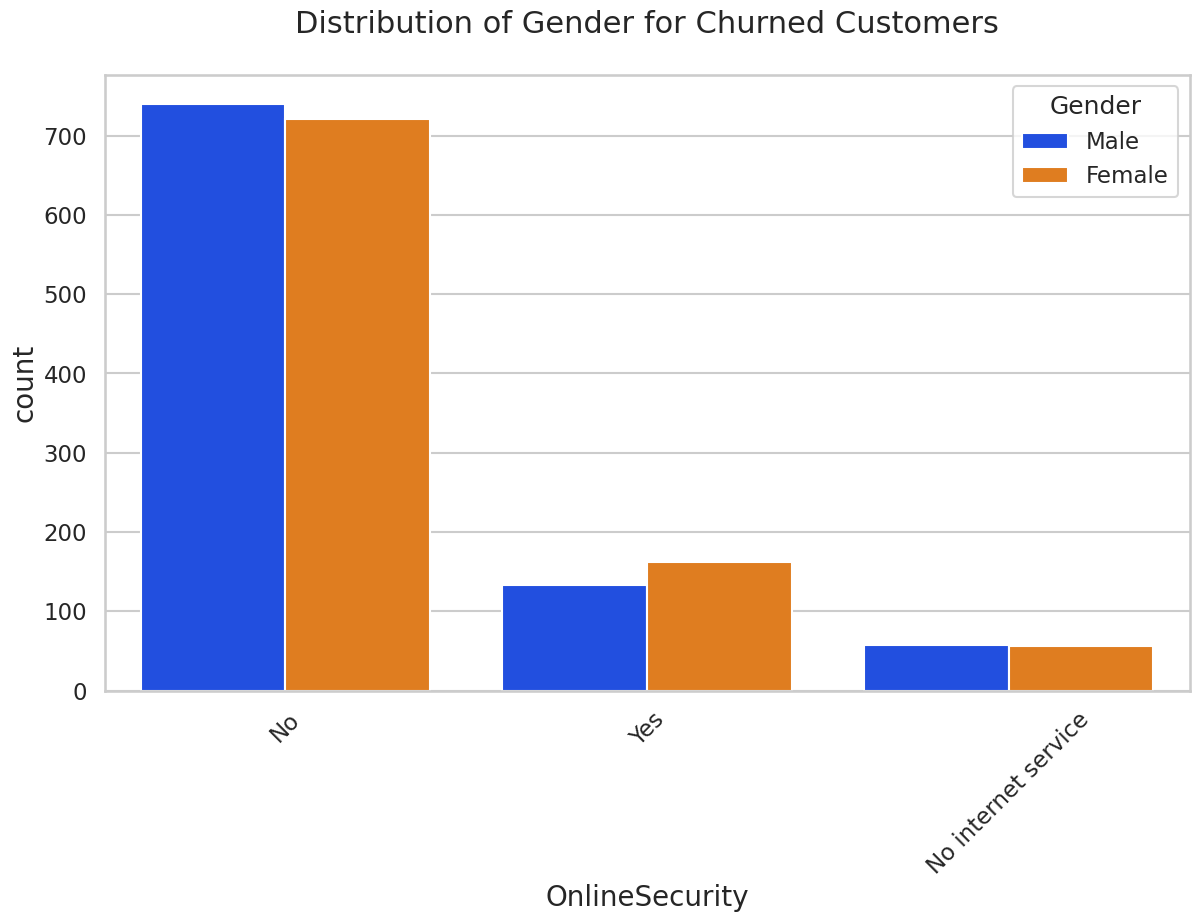

In [142]:
uniplot(df5_target1,col='OnlineSecurity',title='Distribution of Gender for Churned Customers',hue='Gender')

- Females are more churners in Online security yes and males more in no online security

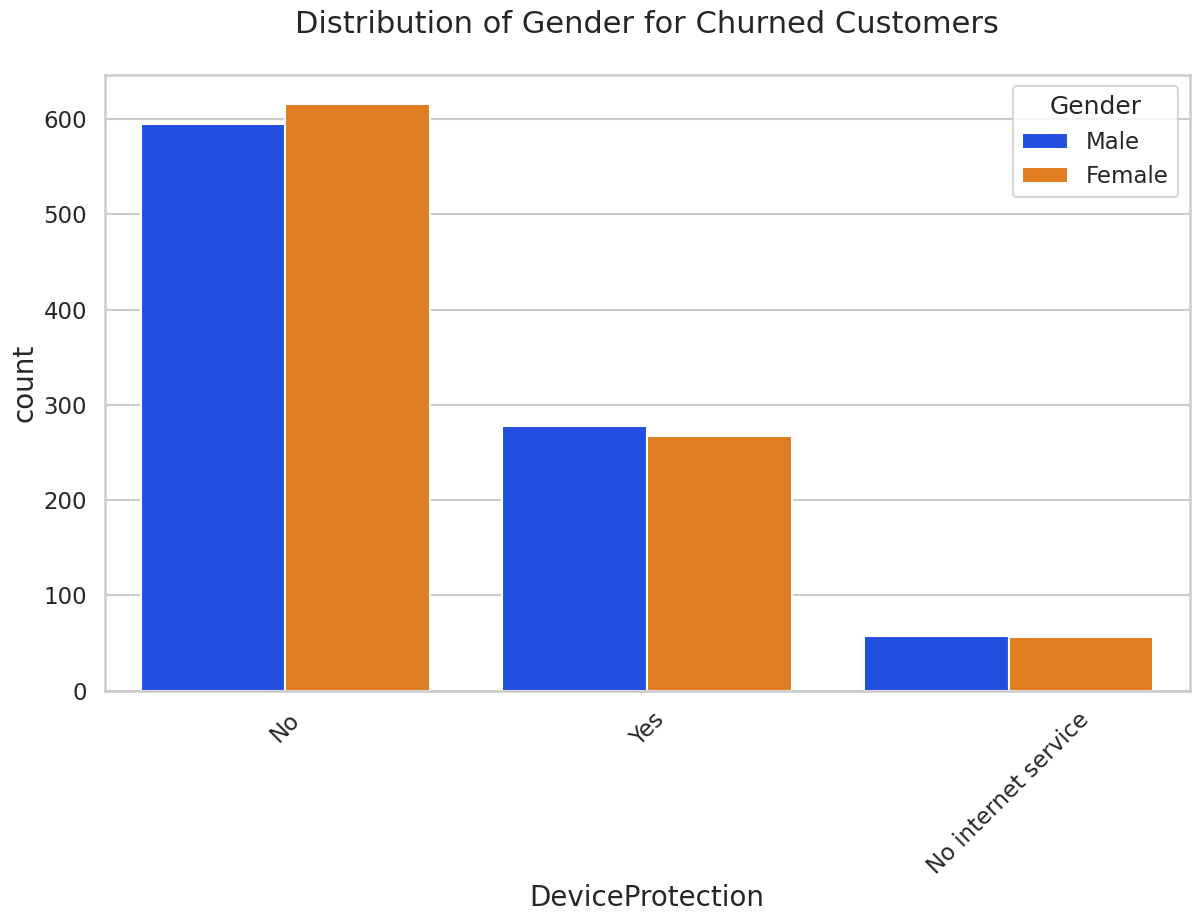

In [143]:
uniplot(df5_target1,col='DeviceProtection',title='Distribution of Gender for Churned Customers',hue='Gender')

- Females more churnernes in device protection-No

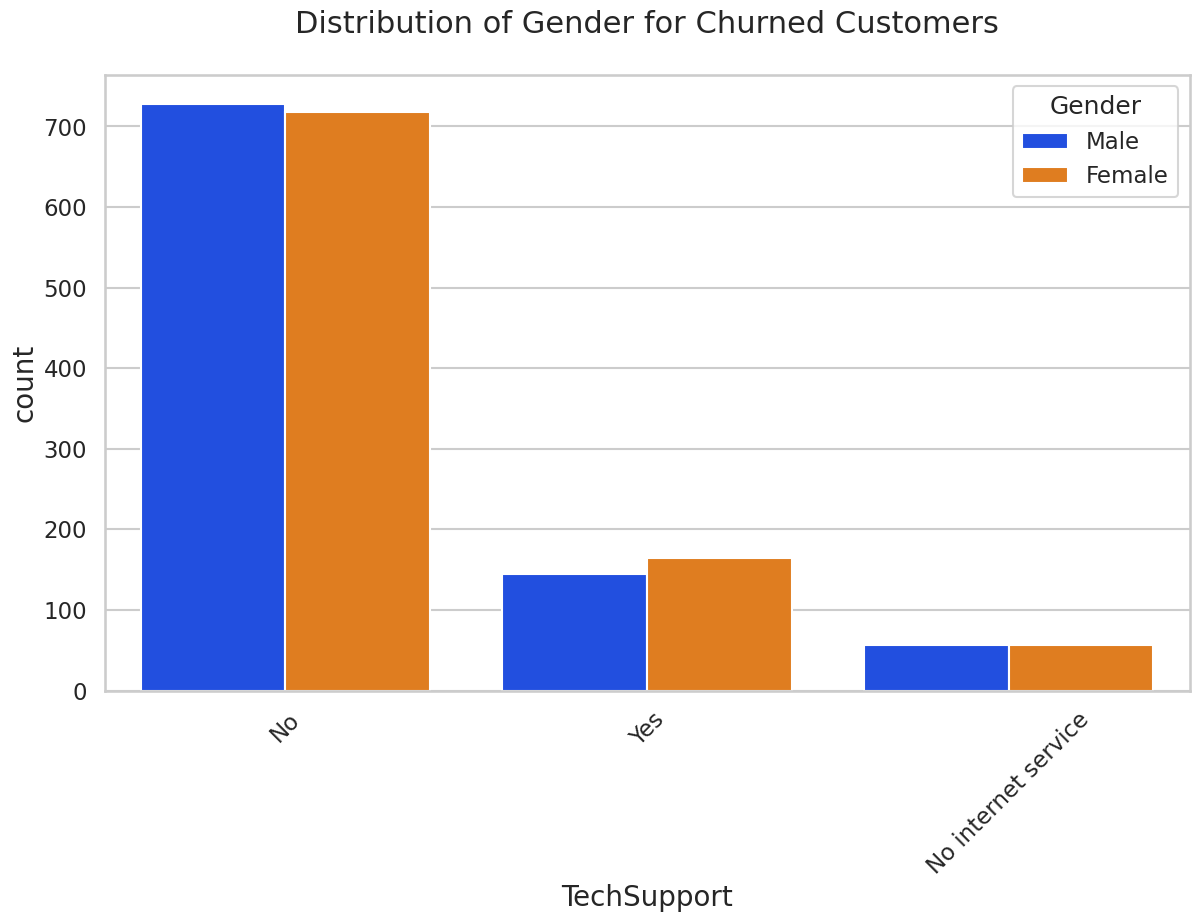

In [144]:
uniplot(df5_target1,col='TechSupport',title='Distribution of Gender for Churned Customers',hue='Gender')

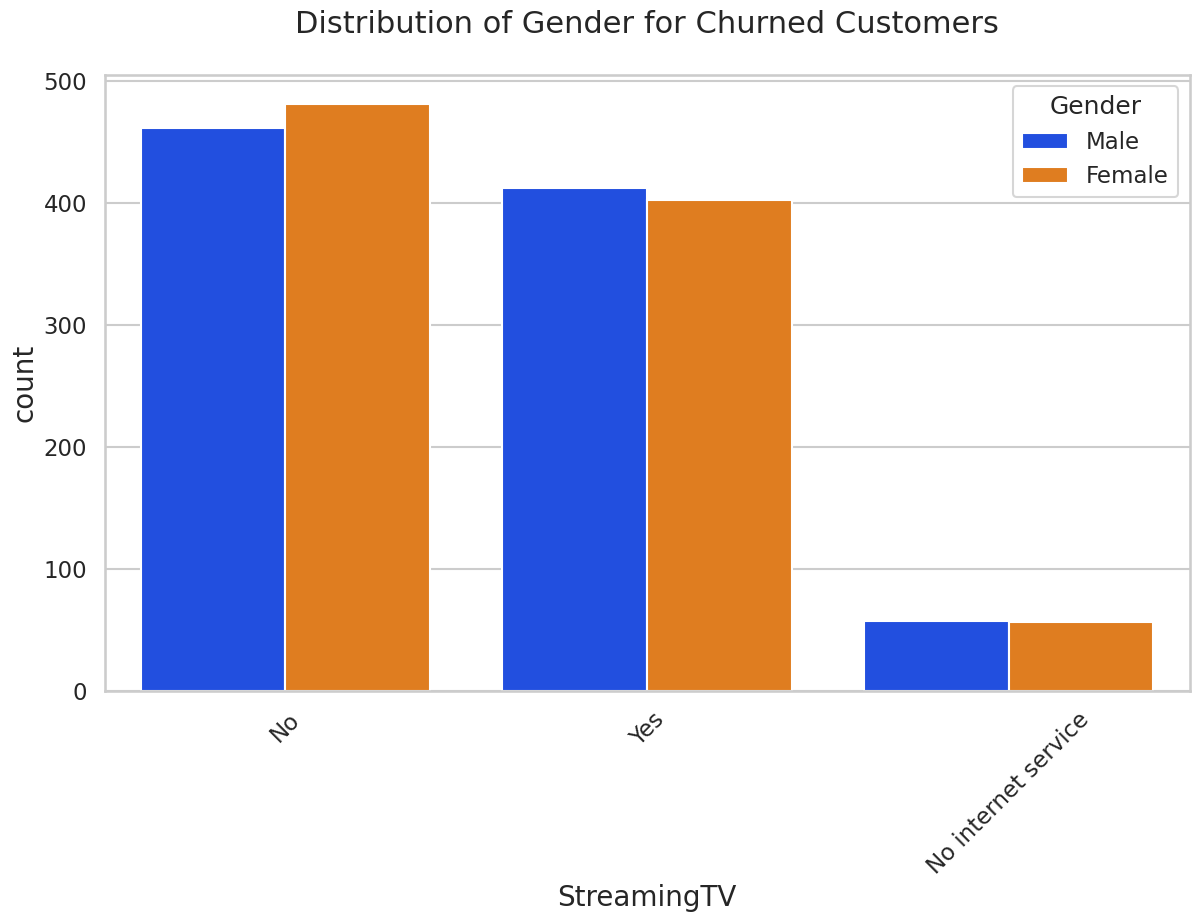

In [145]:
uniplot(df5_target1,col='StreamingTV',title='Distribution of Gender for Churned Customers',hue='Gender')

- females are more churners in StreamingTv-No

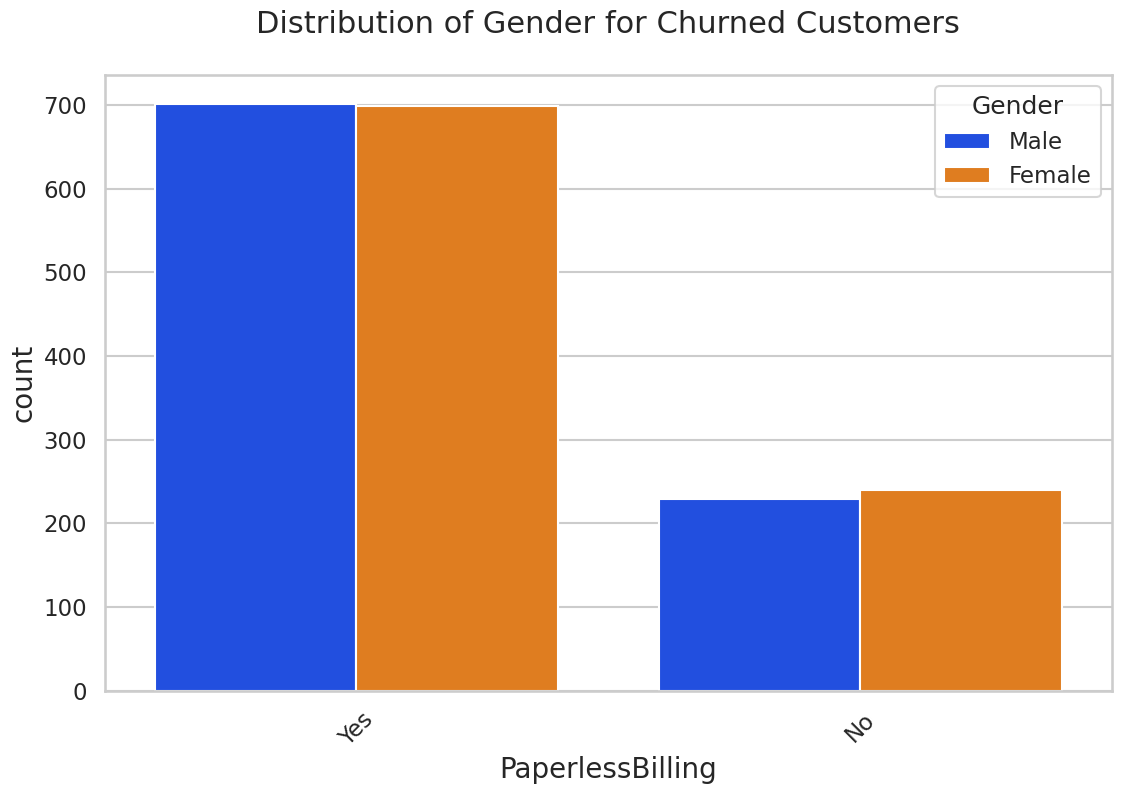

In [146]:
uniplot(df5_target1,col='PaperlessBilling',title='Distribution of Gender for Churned Customers',hue='Gender')

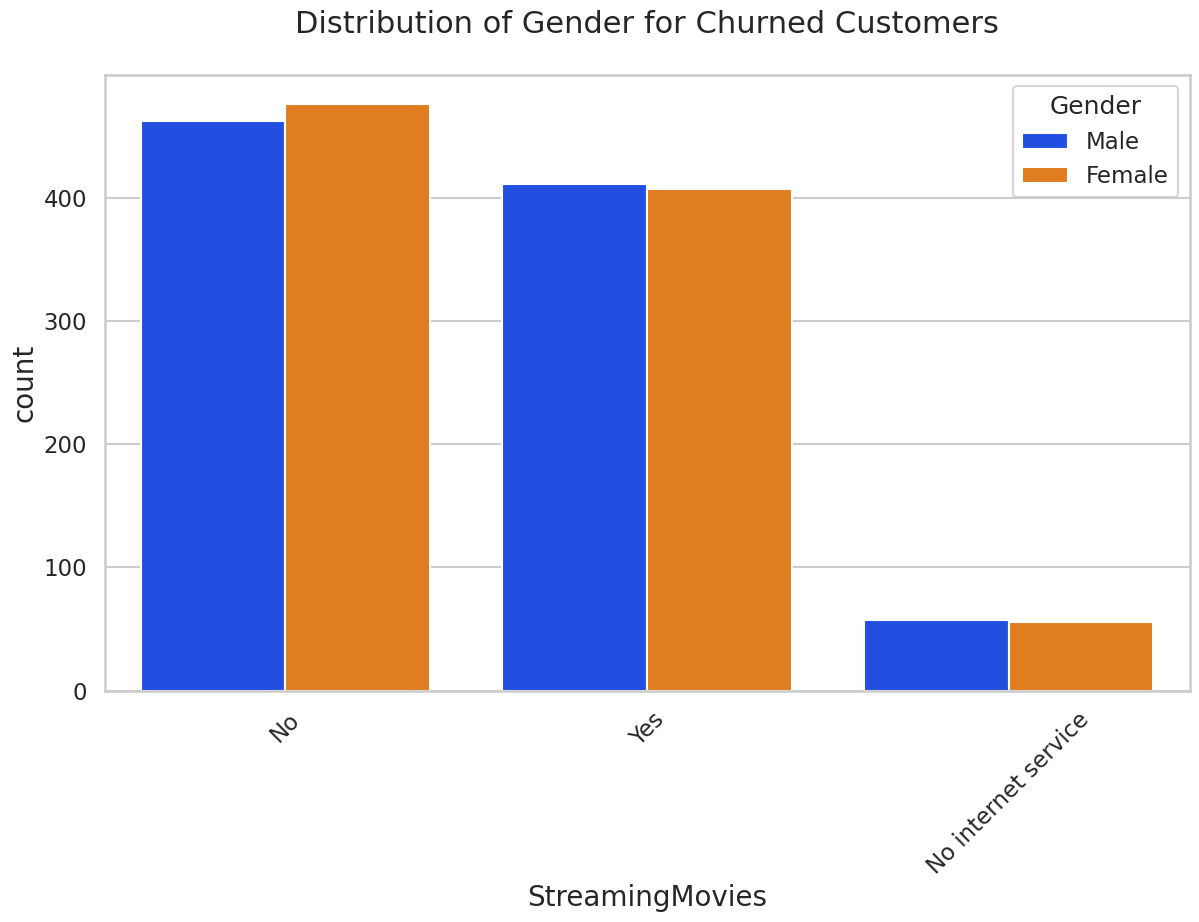

In [147]:
uniplot(df5_target1,col='StreamingMovies',title='Distribution of Gender for Churned Customers',hue='Gender')

In [148]:
df5.head()

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1-12
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,0,25-36
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,1-12
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,37-48
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1-12


#### One-hot encoding

In [149]:
df5_dummy=pd.get_dummies(df5)

In [150]:
df5_dummy.head()

,Tenure,MonthlyCharges,TotalCharges,Churn,Gender_Female,Gender_Male,SeniorCitizen_0,SeniorCitizen_1,Partner_No,Partner_Yes,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_1-12,TenureGroup_13-24,TenureGroup_25-36,TenureGroup_37-48,TenureGroup_49-60,TenureGroup_61-72
0,1,29.85,29.85,0,True,False,True,False,False,True,...,False,False,True,False,True,False,False,False,False,False
1,34,56.95,1889.50,0,False,True,True,False,True,False,...,False,False,False,True,False,False,True,False,False,False
2,2,53.85,108.15,1,False,True,True,False,True,False,...,False,False,False,True,True,False,False,False,False,False
3,45,42.30,1840.75,0,False,True,True,False,True,False,...,True,False,False,False,False,False,False,True,False,False
4,2,70.70,151.65,1,True,False,True,False,True,False,...,False,False,True,False,True,False,False,False,False,False


### Feature Engineering

In [151]:
df_feat_eng= df5_dummy.copy()

In [152]:
#having more services = customer much less likely to churn, clear from univariate and bivariate analysis.
df_feat_eng['ProtectionScore'] = df_feat_eng[['OnlineSecurity_Yes','OnlineBackup_Yes',
                            'DeviceProtection_Yes','TechSupport_Yes']].sum(axis=1)

# New customer (tenure ≤6 months) with bill ≥80$ – this segment is the deadliest, churners way more than others.
df_feat_eng['IsNewHighValue'] = ((df_feat_eng['Tenure'] <= 6) & (df_feat_eng['MonthlyCharges'] >= 80)).astype(int)

# Fiber optic without TechSupport
df_feat_eng['FiberNoSupport'] = ((df_feat_eng['InternetService_Fiber optic'] == 1) &
                        (df_feat_eng['TechSupport_Yes'] == 0)).astype(int)

# Month-to-month + Electronic check
df_feat_eng['M2M_ElectronicCheck'] = ((df_feat_eng['Contract_Two year'] == 0) &
                             (df_feat_eng['PaymentMethod_Electronic check'] == 1)).astype(int)

# Tenure × MonthlyCharges interaction
df_feat_eng['Tenure_x_Charges'] = df_feat_eng['Tenure'] * df_feat_eng['MonthlyCharges']

### EDA on Newly Derived Features

Text(0.5, 0, 'ProtectionScore')

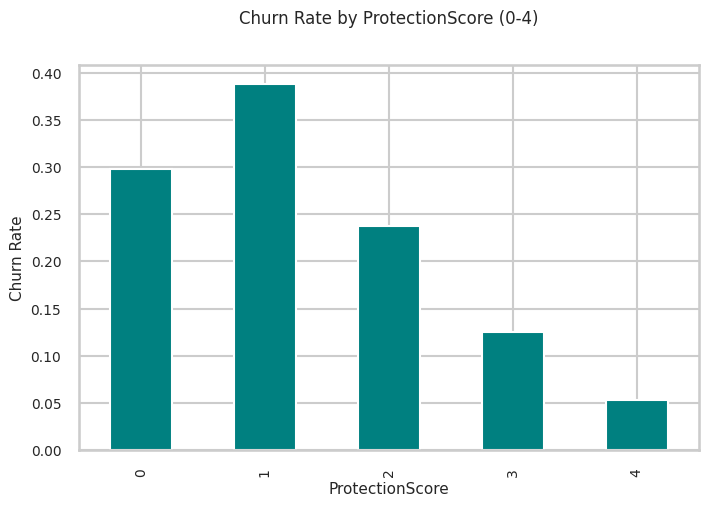

In [193]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df_feat_eng.groupby('ProtectionScore')['Churn'].mean().plot(kind='bar', color='teal')
plt.title('Churn Rate by ProtectionScore (0-4)')
plt.ylabel('Churn Rate')
plt.xlabel('ProtectionScore')

- Churn is higher among customers with low Protection Scores.
- Higher Protection Scores correspond to lower churn.

Text(0, 0.5, 'Count')

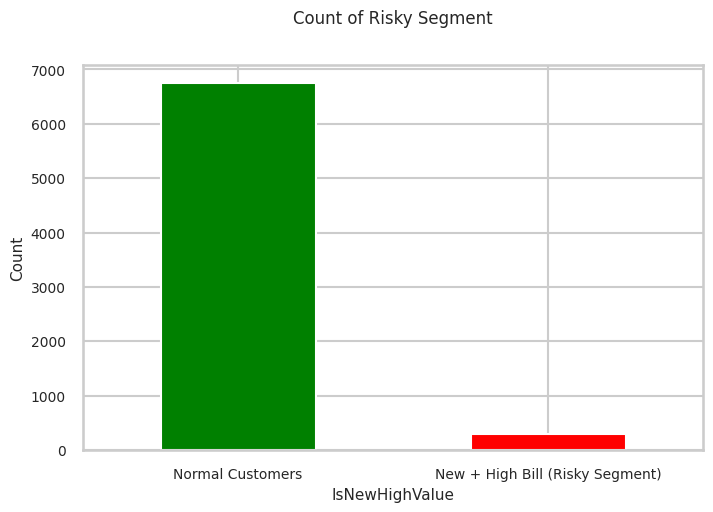

In [186]:
#2. Count of Risky Segment
plt.figure(figsize=(8,5))
df_feat_eng['IsNewHighValue'].value_counts().sort_index().plot(kind='bar', color=['green','red'])
plt.xticks([0,1], ['Normal Customers', 'New + High Bill (Risky Segment)'], rotation=0)
plt.title('Count of Risky Segment', fontsize=12)
plt.ylabel('Count')

- New customer (tenure ≤6 months) with bill ≥80$ – this segment is the deadliest, churners way more than others.

/tmp/ipython-input-3977955443.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_temp.groupby('decile')['Churn'].mean().plot(kind='line', marker='o', color='purple')


Text(0, 0.5, 'Churn Rate')

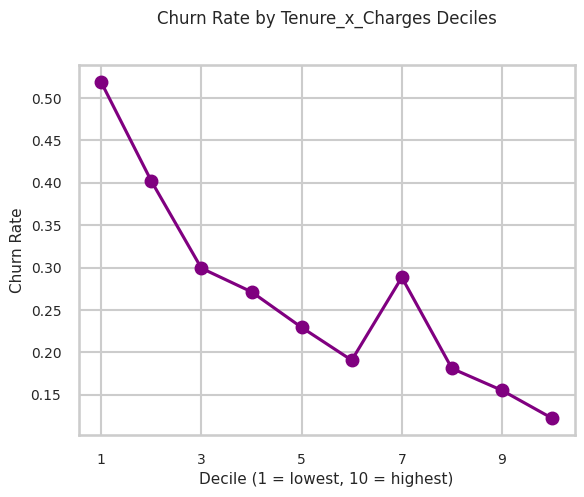

In [187]:
# 3. Tenure_x_Charges decile plot
df_temp = df_feat_eng.copy()
df_temp['decile'] = pd.qcut(df_temp['Tenure_x_Charges'], 10, labels=range(1,11))
df_temp.groupby('decile')['Churn'].mean().plot(kind='line', marker='o', color='purple')
plt.title('Churn Rate by Tenure_x_Charges Deciles')
plt.xlabel('Decile (1 = lowest, 10 = highest)')
plt.ylabel('Churn Rate')

- Customers with the lowest Tenure × MonthlyCharges (new + expensive) churn at ~52%, while those with the highest score (long-tenure + high-value) churn below 10%.

Text(0, 0.5, 'Churn Rate')

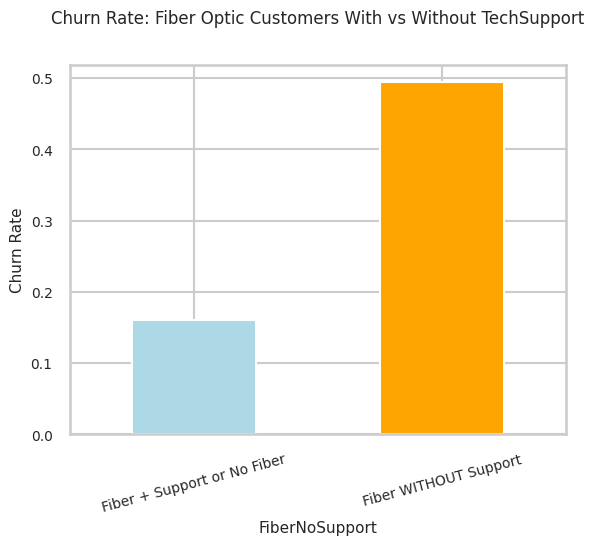

In [194]:
# 4. FiberNoSupport
df_feat_eng.groupby('FiberNoSupport')['Churn'].mean().plot(kind='bar', color=['lightblue','orange'])
plt.xticks([0,1], ['Fiber + Support or No Fiber','Fiber WITHOUT Support'], rotation=15)
plt.title('Churn Rate: Fiber Optic Customers With vs Without TechSupport')
plt.ylabel('Churn Rate')

- Fiber optic customers without TechSupport churn at 49% — over 3× higher than all other customers (15%).

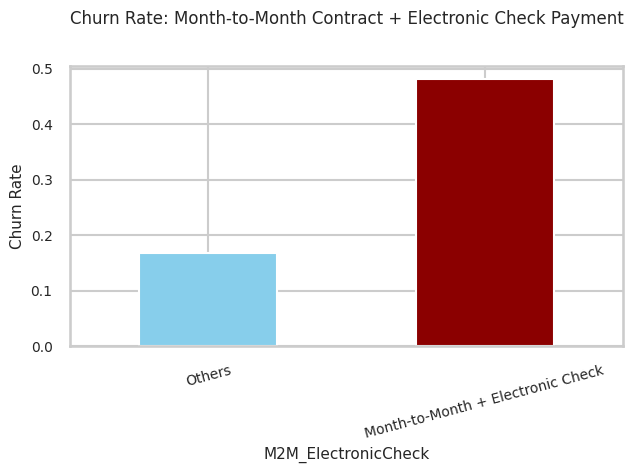

In [195]:
# 5. M2M + Electronic Check
df_feat_eng.groupby('M2M_ElectronicCheck')['Churn'].mean().plot(kind='bar', color=['skyblue','darkred'])
plt.xticks([0,1], ['Others','Month-to-Month + Electronic Check'], rotation=15)
plt.title('Churn Rate: Month-to-Month Contract + Electronic Check Payment')
plt.ylabel('Churn Rate')

plt.tight_layout()
plt.show()

- Customers on Month-to-Month contract + Electronic Check payment churn at 48% — almost 3× higher than the rest of the base (16%).

In [196]:
df_feat_eng.head()

,Tenure,MonthlyCharges,TotalCharges,Churn,Gender_Female,Gender_Male,SeniorCitizen_0,SeniorCitizen_1,Partner_No,Partner_Yes,...,TenureGroup_13-24,TenureGroup_25-36,TenureGroup_37-48,TenureGroup_49-60,TenureGroup_61-72,ProtectionScore,IsNewHighValue,FiberNoSupport,M2M_ElectronicCheck,Tenure_x_Charges
0,1,29.85,29.85,0,True,False,True,False,False,True,...,False,False,False,False,False,1,0,0,1,29.85
1,34,56.95,1889.50,0,False,True,True,False,True,False,...,False,True,False,False,False,2,0,0,0,1936.30
2,2,53.85,108.15,1,False,True,True,False,True,False,...,False,False,False,False,False,2,0,0,0,107.70
3,45,42.30,1840.75,0,False,True,True,False,True,False,...,False,False,True,False,False,3,0,0,0,1903.50
4,2,70.70,151.65,1,True,False,True,False,True,False,...,False,False,False,False,False,0,0,1,1,141.40


In [157]:
# Exporting feature engineered dataset to test Model performance
df_feat_eng.to_csv('tele_churn_feat_eng.csv')